# **Limpieza de datos**

##**1.1: Limpieza y auditoría**

##Importacion de librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Importacion de datos scrapeados

In [ ]:
#Importacion datos de calles
url='https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos%20Contextuales/callejero.csv'
df_calles=pd.read_csv(url)

In [ ]:
#Importacion archivos alquileres
url="https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos2/datos_argenprop_alquiler.tsv"
df_alq_argenprop=pd.read_csv(url, sep='\t')
url="https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos2/datos_remax_alquiler.csv"
df_alq_remax=pd.read_csv(url)

##Vista de datos

###Vista df_calles:

In [ ]:
df_calles.head()

,id,codigo,nomoficial,nom_mapa,nomanter,tipo_c,long,sentido,bicisenda,red_jerarq,...,alt_izqfin,alt_derini,alt_derfin,comuna,com_par,com_impar,barrio,barrio_par,barrio_imp,observa
0,1,3054,"CANTILO, INT.",INT. CANTILO,NaN,CALLE,436.858613,CRECIENTE,NaN,VÍA TRONCAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,NaN
1,2,12152,"LUGONES, LEOPOLDO AV.",AV. LEOPOLDO LUGONES,NaN,AVENIDA,295.580867,CRECIENTE,NaN,VÍA TRONCAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,corrección nombre 9-1-03
2,3,17041,"PAZ, GRAL. AV.",AV.GRAL PAZ,ZUFRIATEGUI(PARCIAL),AVENIDA,145.474786,DECRECIENTE,NaN,VÍA TRONCAL,...,300,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,NaN
3,4,12107,DEL LIBERTADOR AV.,AV.DEL LIBERTADOR,"DEL LIBERTADOR GENERAL SAN MARTIN, Av.(parcial...",AVENIDA,10.152599,DOBLE,NaN,VÍA DISTRIBUIDORA PRINCIPAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,NaN
4,5,3054,"COLECTORA CANTILO, INT.",Colectora INT. CANTILO,"CANTILO, Int.",CALLE,78.551117,CRECIENTE,NaN,VÍA LOCAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,Agregado en el nombre de Colectora por ser par...


In [ ]:
df_calles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31956 entries, 0 to 31955
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          31956 non-null  int64  
 1   codigo      31956 non-null  int64  
 2   nomoficial  31956 non-null  object 
 3   nom_mapa    31910 non-null  object 
 4   nomanter    12480 non-null  object 
 5   tipo_c      31955 non-null  object 
 6   long        31956 non-null  float64
 7   sentido     31955 non-null  object 
 8   bicisenda   7 non-null      object 
 9   red_jerarq  31955 non-null  object 
 10  tipo_ffcc   31955 non-null  object 
 11  alt_izqini  31956 non-null  int64  
 12  alt_izqfin  31956 non-null  int64  
 13  alt_derini  31956 non-null  int64  
 14  alt_derfin  31956 non-null  int64  
 15  comuna      31956 non-null  object 
 16  com_par     31956 non-null  object 
 17  com_impar   31956 non-null  object 
 18  barrio      30227 non-null  object 
 19  barrio_par  31868 non-nul

In [ ]:
df_calles.describe()

,id,codigo,long,alt_izqini,alt_izqfin,alt_derini,alt_derfin
count,31956.000000,31956.000000,31956.000000,31956.000000,31956.000000,31956.000000,31956.000000
mean,16447.716986,15771.227438,108.270889,2289.722493,2360.976092,2254.417856,2325.698836
std,9518.005861,21609.058206,87.528423,2026.232890,2039.180426,1963.506692,1978.170850
min,1.000000,1000.000000,2.727185,0.000000,0.000000,0.000000,0.000000
25%,8256.750000,3202.000000,67.323874,552.000000,600.000000,501.000000,599.000000
50%,16375.500000,12067.000000,103.985444,1902.000000,2000.000000,1901.000000,1999.000000
75%,24550.250000,19053.000000,131.352256,3602.000000,3660.000000,3531.000000,3599.000000
max,33120.000000,200000.000000,3113.053642,17692.000000,17700.000000,17401.000000,17699.000000


In [ ]:
df_calles.shape

(31956, 22)

###Vista df_alq_argenprop

In [ ]:
df_alq_argenprop.head()

,Precio,Expensas,Calle,Altura,Piso,Tipo_Alquiler,Detalles,Descripción,Link,Ambientes,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
0,USD 950,NaN,Manuel Nicolas Savio,400.0,4,Alquiler Temporal,65 m² cubie. 2 dorm. 2 baños,Excelente unidad. Amplio y luminoso departamen...,https://www.argenprop.com/departamento-en-alqu...,3.0,...,0,0,0,0,0,0,0,0,1,0
1,ARS 890.000,NaN,Niceto vega,5900.0,3,Alquiler,47 m² cubie. Monoam. Bueno,ALQUILER - MONOAMBIENTE LUMINOSO EN PALERMO Ub...,https://www.argenprop.com/departamento-en-alqu...,1.0,...,1,0,0,0,0,0,1,0,1,0
2,ARS 1.600.000,ARS 365.000,El Salvador,5500.0,3,Alquiler,80 m² cubie. 2 dorm. 15 años,ALQUILER: $ 1.600.000 ó U$S 1.150. Expensas: $...,https://www.argenprop.com/departamento-en-alqu...,3.0,...,0,0,0,0,0,0,1,0,1,0
3,USD 1.400,ARS 269.000,RODRIGUEZ PEÑA,2000.0,2,Alquiler,100 m² cubie. 2 dorm. 40 años,•ESPECTACULAR DEPARTAMENTO DE CATEGORIA DE 3 A...,https://www.argenprop.com/departamento-en-alqu...,5.0,...,0,0,0,0,0,0,0,0,1,0
4,ARS 900.000,NaN,HONDURAS,4600.0,6,Alquiler,27 m² cubie. 1 baño Monoam.,1 AMBIENTE CON TERRAZA ÚNICA EN PALERMO - AMOE...,https://www.argenprop.com/departamento-en-alqu...,1.0,...,1,0,0,0,0,0,1,0,1,0


In [ ]:
df_alq_argenprop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1978 entries, 0 to 1977
Data columns (total 66 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precio                                       1978 non-null   object 
 1   Expensas                                     1640 non-null   object 
 2   Calle                                        1978 non-null   object 
 3   Altura                                       1859 non-null   float64
 4   Piso                                         1196 non-null   object 
 5   Tipo_Alquiler                                1978 non-null   object 
 6   Detalles                                     1967 non-null   object 
 7   Descripción                                  1978 non-null   object 
 8   Link                                         1978 non-null   object 
 9   Ambientes                                    1916 non-null   float64
 10  

In [ ]:
df_alq_argenprop.describe()

,Altura,Ambientes,Dormitorios,Baños,Toilettes,Antiguedad,Expensas_Ficha,Cant_Pisos_Edificio,Deptos_Por_Piso,Antiguedad_Edificio,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
count,1859.000000,1916.000000,1472.000000,1831.000000,160.000000,1393.000000,0.0,703.000000,632.000000,0.0,...,1978.000000,1978.0,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000,1978.000000
mean,2163.254438,2.141962,1.527174,1.198252,1.050000,31.681263,NaN,9.174964,3.927215,NaN,...,0.050051,0.0,0.041456,0.055106,0.164813,0.162791,0.305359,0.062690,0.632963,0.059656
std,1691.696253,1.015644,0.769451,0.509492,0.218629,19.933411,NaN,4.785049,3.478403,NaN,...,0.218104,0.0,0.199393,0.228245,0.371105,0.369268,0.460676,0.242465,0.482119,0.236909
min,3.000000,0.000000,1.000000,1.000000,1.000000,-1.000000,NaN,1.000000,1.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,800.000000,1.000000,1.000000,1.000000,1.000000,12.000000,NaN,7.000000,2.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1900.000000,2.000000,1.000000,1.000000,1.000000,35.000000,NaN,9.000000,4.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,3000.000000,3.000000,2.000000,1.000000,1.000000,45.000000,NaN,11.000000,4.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,13100.000000,11.000000,6.000000,5.000000,2.000000,150.000000,NaN,44.000000,66.000000,NaN,...,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_alq_argenprop.shape

(1978, 66)

###Vista df_alq_remax

In [ ]:
df_alq_remax.head()

,Precio,Expensas,Calle,Altura,Piso,Link,Ambientes,Dormitorios,Baños,Toilettes,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
0,790.000 ARS,160.000 ARS,Doctor Nicolás Repetto,0.0,NaN,https://www.remax.com.ar/listings/caballito-al...,3.0,2.0,1.0,NaN,...,0,0,0,0,0,0,1,0,1,0
1,1.050.000 ARS,180.000 ARS,CURAPALIGUE,300.0,NaN,https://www.remax.com.ar/listings/departamento...,2.0,1.0,1.0,NaN,...,0,0,0,0,0,0,1,0,1,0
2,1.200.000 ARS,140.000 ARS,Teodoro Garcia,3100.0,NaN,https://www.remax.com.ar/listings/alquiler-dpt...,2.0,1.0,1.0,NaN,...,1,0,0,0,0,0,1,0,1,0
3,790 USD,206.000 ARS,José Andrés Pacheco de Melo,2000.0,NaN,https://www.remax.com.ar/listings/alquiler-de-...,2.0,1.0,1.0,NaN,...,1,0,0,0,0,0,1,0,1,0
4,520.000 ARS,160.500 ARS,JUNIN,200.0,NaN,https://www.remax.com.ar/listings/alquiler-de-...,2.0,1.0,1.0,NaN,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
df_alq_remax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2055 entries, 0 to 2054
Data columns (total 63 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precio                                       1984 non-null   object 
 1   Expensas                                     1705 non-null   object 
 2   Calle                                        1989 non-null   object 
 3   Altura                                       1989 non-null   float64
 4   Piso                                         0 non-null      float64
 5   Link                                         2055 non-null   object 
 6   Ambientes                                    1618 non-null   float64
 7   Dormitorios                                  1297 non-null   float64
 8   Baños                                        1914 non-null   float64
 9   Toilettes                                    322 non-null    float64
 10  

In [ ]:
df_alq_remax.describe()

,Altura,Piso,Ambientes,Dormitorios,Baños,Toilettes,Tipo_Balcon,Tipo_Unidad,Tipo_Operacion,Precio_Ficha,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
count,1989.000000,0.0,1618.000000,1297.000000,1914.00000,322.000000,0.0,0.0,0.0,0.0,...,2055.000000,2055.000000,2055.000000,2055.000000,2055.0,2055.000000,2055.000000,2055.000000,2055.000000,2055.000000
mean,2133.986928,NaN,2.213844,1.588281,1.38976,1.083851,NaN,NaN,NaN,NaN,...,0.141119,0.071046,0.022384,0.002433,0.0,0.001946,0.967883,0.092944,0.967883,0.049635
std,1657.888054,NaN,1.218292,0.979789,2.43292,0.525772,NaN,NaN,NaN,NaN,...,0.348229,0.256965,0.147966,0.049278,0.0,0.044087,0.176353,0.290425,0.176353,0.217243
min,0.000000,NaN,1.000000,1.000000,1.00000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,900.000000,NaN,1.000000,1.000000,1.00000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,0.000000
50%,1800.000000,NaN,2.000000,1.000000,1.00000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,0.000000
75%,3000.000000,NaN,3.000000,2.000000,1.00000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,0.000000
max,13100.000000,NaN,18.000000,17.000000,100.00000,8.000000,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_alq_remax.shape

(2055, 63)

##Concatenacion de bases de datos

In [ ]:
# Agregar columna de origen antes de concatenar para luego saber de donde vienen los datos
df_alq_argenprop['fuente'] = 'argenprop'
df_alq_remax['fuente'] = 'remax'

# Unificamos los df de alquileres
df_alquiler_completo = pd.concat([df_alq_argenprop, df_alq_remax], ignore_index=True)

print(f"Registros Argenprop: {len(df_alq_argenprop)}")
print(f"Registros Remax: {len(df_alq_remax)}")
print(f"Total combinado: {len(df_alquiler_completo)}")
print(f"\nColumnas: {df_alquiler_completo.columns.tolist()}")

Registros Argenprop: 1978
Registros Remax: 2055
Total combinado: 4033

Columnas: ['Precio', 'Expensas', 'Calle', 'Altura', 'Piso', 'Tipo_Alquiler', 'Detalles', 'Descripción', 'Link', 'Ambientes', 'Dormitorios', 'Baños', 'Toilettes', 'Estado', 'Antiguedad', 'Disposicion', 'Orientacion', 'Tipo_Balcon', 'Apto_Profesional', 'Apto_Credito', 'Tipo_Unidad', 'Tipo_Operacion', 'Sup_Cubierta_m2', 'Sup_Total_m2', 'Sup_Descubierta_m2', 'Precio_Ficha', 'Expensas_Ficha', 'Cant_Pisos_Edificio', 'Deptos_Por_Piso', 'Antiguedad_Edificio', 'Estado_Edificio', 'Aire_acondicionado_individual', 'Electricidad', 'Losa_radiante', 'Gas_natural', 'Agua_corriente', 'Agua_caliente', 'Balcón', 'Terraza', 'Jardín', 'Patio', 'Baulera', 'Cochera', 'Muebles_de_cocina', 'Lavarropas', 'Lavavajillas', 'Conexión_para_lavarropas', 'Permite_Mascotas', 'Apto_Crédito', 'Ascensor', 'Pileta', 'Piscina', 'Parrilla', 'SUM', 'Gimnasio', 'Sauna', 'Laundry', 'Seguridad_24hs', 'Vigilancia', 'Acceso_para_personas_con_movilidad_reducida'

##Unificacion de columnas repetidas

In [ ]:
#Unificacion columnas de df_alquiler_completo
# 1. Unificar Precio
df_alquiler_completo['Precio'] = df_alquiler_completo['Precio'].fillna(df_alquiler_completo['Precio_Ficha'])
df_alquiler_completo.drop('Precio_Ficha', axis=1, inplace=True)

# 2. Unificar Expensas
df_alquiler_completo['Expensas'] = df_alquiler_completo['Expensas'].fillna(df_alquiler_completo['Expensas_Ficha'])
df_alquiler_completo.drop('Expensas_Ficha', axis=1, inplace=True)

# 3. Unificar Apto_Credito (sin tilde)
df_alquiler_completo['Apto_Credito'] = df_alquiler_completo['Apto_Credito'].fillna(df_alquiler_completo['Apto_Crédito'])
df_alquiler_completo.drop('Apto_Crédito', axis=1, inplace=True)

# 4. Unificar Pileta/Piscina
df_alquiler_completo['Pileta'] = df_alquiler_completo['Pileta'].fillna(df_alquiler_completo['Piscina'])
df_alquiler_completo.drop('Piscina', axis=1, inplace=True)

# 5. Unificar Balcón (mantener binario, eliminar Tipo_Balcon)
df_alquiler_completo['Balcón'] = df_alquiler_completo['Balcón'].fillna(
    df_alquiler_completo['Tipo_Balcon'].notna()
)
df_alquiler_completo.drop('Tipo_Balcon', axis=1, inplace=True)

# 6. Unificar Seguridad
df_alquiler_completo['Seguridad_24hs'] = (
    df_alquiler_completo['Seguridad_24hs'].fillna(False) |
    df_alquiler_completo['Vigilancia'].fillna(False)
)
df_alquiler_completo.drop('Vigilancia', axis=1, inplace=True)

# 7. Unificar Antiguedad
df_alquiler_completo['Antiguedad'] = df_alquiler_completo['Antiguedad'].fillna(df_alquiler_completo['Antiguedad_Edificio'])
df_alquiler_completo.drop('Antiguedad_Edificio', axis=1, inplace=True)

# 8. Unificar Estado
df_alquiler_completo['Estado'] = df_alquiler_completo['Estado'].fillna(df_alquiler_completo['Estado_Edificio'])
df_alquiler_completo.drop('Estado_Edificio', axis=1, inplace=True)

print(f"Columnas después de unificar: {len(df_alquiler_completo.columns)}")
print(f"Registros totales: {len(df_alquiler_completo)}")
print(f"Filas: {len(df_alquiler_completo)} | Columnas: {len(df_alquiler_completo.columns)}")
print(sorted(df_alquiler_completo.columns.tolist()))

Columnas después de unificar: 59
Registros totales: 4033
Filas: 4033 | Columnas: 59
['ABL', 'Acceso_para_personas_con_movilidad_reducida', 'Agua_caliente', 'Agua_corriente', 'Aire_acondicionado_individual', 'Altura', 'Ambientes', 'Antiguedad', 'Apto_Credito', 'Apto_Profesional', 'Ascensor', 'Balcón', 'Baulera', 'Baños', 'Calle', 'Cant_Pisos_Edificio', 'Cochera', 'Conexión_para_lavarropas', 'Deptos_Por_Piso', 'Descripción', 'Detalles', 'Disposicion', 'Dormitorios', 'Electricidad', 'Estado', 'Expensas', 'Gas_natural', 'Gimnasio', 'Jardín', 'Laundry', 'Lavarropas', 'Lavavajillas', 'Link', 'Losa_radiante', 'Muebles_de_cocina', 'Orientacion', 'Parrilla', 'Patio', 'Pavimento', 'Permite_Mascotas', 'Pileta', 'Piso', 'Precio', 'SUM', 'Sauna', 'Seguridad_24hs', 'Smart_Amenities', 'Smart_Balcon_Aterrazado', 'Smart_Losa_Central', 'Smart_Luminoso', 'Sup_Cubierta_m2', 'Sup_Descubierta_m2', 'Sup_Total_m2', 'Terraza', 'Tipo_Alquiler', 'Tipo_Operacion', 'Tipo_Unidad', 'Toilettes', 'fuente']


##Vista de los df completos

In [ ]:
df_alquiler_completo.head()

,Precio,Expensas,Calle,Altura,Piso,Tipo_Alquiler,Detalles,Descripción,Link,Ambientes,...,Laundry,Seguridad_24hs,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado,fuente
0,USD 950,NaN,Manuel Nicolas Savio,400.0,4,Alquiler Temporal,65 m² cubie. 2 dorm. 2 baños,Excelente unidad. Amplio y luminoso departamen...,https://www.argenprop.com/departamento-en-alqu...,3.0,...,0,0,0,0,0,0,0,1,0,argenprop
1,ARS 890.000,NaN,Niceto vega,5900.0,3,Alquiler,47 m² cubie. Monoam. Bueno,ALQUILER - MONOAMBIENTE LUMINOSO EN PALERMO Ub...,https://www.argenprop.com/departamento-en-alqu...,1.0,...,1,0,0,0,0,1,0,1,0,argenprop
2,ARS 1.600.000,ARS 365.000,El Salvador,5500.0,3,Alquiler,80 m² cubie. 2 dorm. 15 años,ALQUILER: $ 1.600.000 ó U$S 1.150. Expensas: $...,https://www.argenprop.com/departamento-en-alqu...,3.0,...,0,0,0,0,0,1,0,1,0,argenprop
3,USD 1.400,ARS 269.000,RODRIGUEZ PEÑA,2000.0,2,Alquiler,100 m² cubie. 2 dorm. 40 años,•ESPECTACULAR DEPARTAMENTO DE CATEGORIA DE 3 A...,https://www.argenprop.com/departamento-en-alqu...,5.0,...,0,0,0,0,0,0,0,1,0,argenprop
4,ARS 900.000,NaN,HONDURAS,4600.0,6,Alquiler,27 m² cubie. 1 baño Monoam.,1 AMBIENTE CON TERRAZA ÚNICA EN PALERMO - AMOE...,https://www.argenprop.com/departamento-en-alqu...,1.0,...,1,0,0,0,0,1,0,1,0,argenprop


In [ ]:
df_alquiler_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4033 entries, 0 to 4032
Data columns (total 59 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precio                                       3962 non-null   object 
 1   Expensas                                     3345 non-null   object 
 2   Calle                                        3967 non-null   object 
 3   Altura                                       3848 non-null   float64
 4   Piso                                         1196 non-null   object 
 5   Tipo_Alquiler                                1978 non-null   object 
 6   Detalles                                     1967 non-null   object 
 7   Descripción                                  1978 non-null   object 
 8   Link                                         4033 non-null   object 
 9   Ambientes                                    3534 non-null   float64
 10  

In [ ]:
df_alquiler_completo.describe()

,Altura,Ambientes,Dormitorios,Baños,Toilettes,Cant_Pisos_Edificio,Deptos_Por_Piso,Aire_acondicionado_individual,Electricidad,Losa_radiante,...,Sauna,Laundry,Seguridad_24hs,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
count,3848.000000,3534.000000,2769.000000,3745.000000,482.000000,703.000000,632.000000,4033.000000,4033.000000,4033.000000,...,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000
mean,2148.126299,2.174873,1.555796,1.296128,1.072614,9.174964,3.927215,0.326060,0.469130,0.055294,...,0.024300,0.096454,0.066452,0.028267,0.080833,0.080833,0.642946,0.078106,0.803620,0.054550
std,1674.152285,1.113427,0.874665,1.777756,0.447814,4.785049,3.478403,0.468828,0.499108,0.228581,...,0.153997,0.295250,0.249101,0.165755,0.272612,0.272612,0.479190,0.268371,0.397308,0.227128
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,900.000000,1.000000,1.000000,1.000000,1.000000,7.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1840.500000,2.000000,1.000000,1.000000,1.000000,9.000000,4.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,3000.000000,3.000000,2.000000,1.000000,1.000000,11.000000,4.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,13100.000000,18.000000,17.000000,100.000000,8.000000,44.000000,66.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_alquiler_completo.shape

(4033, 59)

##**1.2: Tratamiento y analisis de datos duplicados**

Detectamos duplicados en tres niveles:
1. **Duplicados exactos:** filas idénticas en todas las columnas (errores de scraping con doble inserción).
2. **Duplicados por Link:** misma URL publicada dos veces en una fuente.
3. **Duplicados inter-fuente:** misma propiedad publicada en distintos portales.
   Criterio: misma `(Calle, Altura, Sup_Cubierta_m2, Ambientes)` y precio dentro del 5%.
   Conservamos el registro con menos nulos (más información).
   

In [ ]:
def reporte_duplicados(df, nombre):
    print(f"\n=== {nombre} ===")
    print(f"Filas iniciales: {len(df)}")
    print(f"Duplicados exactos: {df.duplicated().sum()}")
    if 'Link' in df.columns:
        print(f"Duplicados por Link: {df.duplicated(subset=['Link']).sum()}")

reporte_duplicados(df_alquiler_completo, 'Alquileres')


=== Alquileres ===
Filas iniciales: 4033
Duplicados exactos: 0
Duplicados por Link: 0


In [ ]:
def deduplicar(df):
    n0 = len(df)

    # 1. Duplicados exactos
    df = df.drop_duplicates().copy()
    n1 = len(df)

    # 2. Duplicados por Link
    if 'Link' in df.columns:
        df = df.drop_duplicates(subset=['Link'], keep='first').copy()
    n2 = len(df)

    # 3. Detectar (pero NO eliminar) duplicados inter-fuente
    # Creamos una marca para identificarlos
    df['_dup_interfuente'] = df.duplicated(
        subset=['Calle', 'Altura', 'Sup_Cubierta_m2', 'Ambientes'],
        keep=False
    )

    n3 = len(df)  # no cambia porque no eliminamos

    print(f"  Exactos eliminados: {n0 - n1}")
    print(f"  Por Link eliminados: {n1 - n2}")
    print(f"  Inter-fuente detectados (NO eliminados): {df['_dup_interfuente'].sum()}")
    print(f"  Total: {n0} -> {n3} ({n0-n3} eliminados, {(n0-n3)/n0*100:.1f}%)")

    return df


print("\nAlquileres:")
df_alquiler_completo = deduplicar(df_alquiler_completo)


Alquileres:
  Exactos eliminados: 0
  Por Link eliminados: 0
  Inter-fuente detectados (NO eliminados): 292
  Total: 4033 -> 4033 (0 eliminados, 0.0%)


Los datos identificados como "inter-fuente" no fueron eliminados ya que se puede tratar de departamentos distintos de un mismo edificio. Igualmente, decidimos detectarlos y discriminarlos para un futuro analisis.

##**1.3: Diagnóstico y tratamiento de nulos**

In [ ]:
porcentaje_nulos=(df_alquiler_completo.isna().sum()/len(df_alquiler_completo))*100 #Calculo del porcentaje de valores nulos
print("Porcentaje de valores nulos en el dataframe completo de alquiler")
print(porcentaje_nulos.round(2))

Porcentaje de valores nulos en el dataframe completo de alquiler
Precio                                          1.76
Expensas                                       17.06
Calle                                           1.64
Altura                                          4.59
Piso                                           70.34
Tipo_Alquiler                                  50.95
Detalles                                       51.23
Descripción                                    50.95
Link                                            0.00
Ambientes                                      12.37
Dormitorios                                    31.34
Baños                                           7.14
Toilettes                                      88.05
Estado                                         60.72
Antiguedad                                     64.94
Disposicion                                    42.62
Orientacion                                    64.52
Apto_Profesional                  

En base a este analisis, podemos identificar que hay varias variables tales como 'Piso', 'Tipo_Unidad', 'Cant_Pisos_Edificio', 'Deptos_Por_Piso', y 'Barrio_remax_orig' que poseen un gran porcentaje de valores nulos por lo que habra que revisar si tienen sentido y si son variables que realmente aportan informacion al modelo a armar.

####Precio:

La variable Precio presentó un porcentaje muy reducido de valores faltantes. Dado que se trata de una variable central para el análisis económico e inmobiliario, se decidió eliminar dichos registros en lugar de imputarlos, evitando introducir sesgos artificiales en métricas derivadas como el precio por metro cuadrado.

In [ ]:
df_alquiler_completo = df_alquiler_completo[
    df_alquiler_completo['Precio'].notna()
].copy()

####Altura:

In [ ]:
valores_invalidos = df_alquiler_completo[
    pd.to_numeric(df_alquiler_completo['Altura'], errors='coerce').isnull()
]['Altura']

valores_invalidos.unique()

df_alquiler_completo['Altura'] = pd.to_numeric(
    df_alquiler_completo['Altura'],
    errors='coerce'
)

In [ ]:
# revisar cuántos faltantes quedan
df_alquiler_completo['Altura'].isnull().mean()*100

np.float64(3.0035335689045937)

In [ ]:
# revisar calles que terminan en numeros
df_alquiler_completo[
    df_alquiler_completo['Altura'].isnull()
]['Calle'].str.extract(r'(\d+)$').dropna()

,0


In [ ]:
df_alquiler_completo[
    df_alquiler_completo['Altura'].isnull()
][['Calle']].sample(30, random_state=42)

,Calle
1002,AV. JUAN DE GARAY al 2200 14°
1665,Lautaro
69,Azcuenaga y Pacheco de Melo
705,Arenales y Larrea
286,Ecuador al 500 2 ambientes
1975,Marcelo T. de Alvear e/ Riobamba y Ayacucho
1284,Álvarez Thomas y Cespedes
112,Guatemala 5653 5° entre Fitz Roy y Bonpland
1683,Paraná 350 e/ Avenida Corrientes y Sarmiento
1324,Bucarelli al 2200 Av. Olazabal y Blanco Encalada


In [ ]:
#busca la altura en los datos de la calle
df_alquiler_completo['Altura_extraida'] = (
    df_alquiler_completo['Calle']
    .str.extract(r'\s(\d{1,4})\s')[0]
)

In [ ]:
df_alquiler_completo['Altura_extraida'] = pd.to_numeric(
    df_alquiler_completo['Altura_extraida'],
    errors='coerce'
)

In [ ]:
#completar donde falte
mask = df_alquiler_completo['Altura'].isnull()

df_alquiler_completo.loc[mask, 'Altura'] = (
    df_alquiler_completo.loc[mask, 'Altura_extraida']
)

In [ ]:
df_alquiler_completo = df_alquiler_completo.drop(columns=['Altura_extraida'])

####Piso

In [ ]:
#extraer el piso de los datos de la variable calle
df_alquiler_completo['Piso_extraido'] = (
    df_alquiler_completo['Calle']
    .str.extract(r'(\d+)\s*°')[0]
)

In [ ]:
df_alquiler_completo['Piso_extraido'] = pd.to_numeric(
    df_alquiler_completo['Piso_extraido'],
    errors='coerce'
)

In [ ]:
#completar la variable piso solo donde falta
mask = df_alquiler_completo['Piso'].isnull()

df_alquiler_completo.loc[mask, 'Piso'] = (
    df_alquiler_completo.loc[mask, 'Piso_extraido']
)

In [ ]:
df_alquiler_completo['Piso'].isnull().sum()

np.int64(2728)

In [ ]:
df_alquiler_completo['Piso'].isnull().mean()*100

np.float64(68.85411408379606)

In [ ]:
#Eliminacion de la variable 'Piso' debido a la gran cantidad de valores faltantes que posee a pesar de haber podido reducir los faltantes
df_alquiler_completo = df_alquiler_completo.drop(columns=['Piso','Piso_extraido'])

####Deptos_Por_Piso:

In [ ]:
#Eliminacion de la variable 'Deptos_Por_Piso' debido a la gran cantidad de valores faltantes y que no aporta valor estadistico.
df_alquiler_completo = df_alquiler_completo.drop(columns=['Deptos_Por_Piso'])

####Cant_Pisos_Edificio:

In [ ]:
#Eliminacion de la variable 'Cant_Pisos_Edificio' debido a la gran cantidad de valores faltantes y que no aporta valor estadistico.
df_alquiler_completo = df_alquiler_completo.drop(columns=['Cant_Pisos_Edificio'])

####Toilettes:

In [ ]:
#Eliminacion de la variable 'Toilettes' debido a la gran cantidad de valores faltantes y que no aporta valor estadistico.
df_alquiler_completo=df_alquiler_completo.drop(columns=['Toilettes'])

####Baños

In [ ]:
df_alquiler_completo.loc[df_alquiler_completo['Baños']==0, 'fuente'].value_counts()

,count
fuente,


In [ ]:
df_alquiler_completo['Baños'] = (
    df_alquiler_completo
    .groupby(['Tipo_Unidad', 'Ambientes'])['Baños']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

In [ ]:
df_alquiler_completo['Baños'] = (
    df_alquiler_completo['Baños']
    .fillna(
        df_alquiler_completo['Baños'].median()
    )
)

In [ ]:
df_alquiler_completo['Baños'] = (
    df_alquiler_completo['Baños']
    .round()
    .astype('Int64')
)

####Superficies:

In [ ]:
cols = [
    'Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2'
]

for col in cols:
    df_alquiler_completo[col] = (
        df_alquiler_completo[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df_alquiler_completo[col] = pd.to_numeric(df_alquiler_completo[col], errors='coerce')

In [ ]:
#Si falta Total:
mask = (
    df_alquiler_completo['Sup_Total_m2'].isna() &
    df_alquiler_completo['Sup_Cubierta_m2'].notna() &
    df_alquiler_completo['Sup_Descubierta_m2'].notna()
)

df_alquiler_completo.loc[mask, 'Sup_Total_m2'] = (
    df_alquiler_completo.loc[mask, 'Sup_Cubierta_m2'] +
    df_alquiler_completo.loc[mask, 'Sup_Descubierta_m2']
)

In [ ]:
#Si falta Cubierta:
mask = (
    df_alquiler_completo['Sup_Cubierta_m2'].isna() &
    df_alquiler_completo['Sup_Total_m2'].notna() &
    df_alquiler_completo['Sup_Descubierta_m2'].notna()
)

df_alquiler_completo.loc[mask, 'Sup_Cubierta_m2'] = (
    df_alquiler_completo.loc[mask, 'Sup_Total_m2'] -
    df_alquiler_completo.loc[mask, 'Sup_Descubierta_m2']
).clip(lower=0)

In [ ]:
#Si falta Descubierta:
mask = (
    df_alquiler_completo['Sup_Descubierta_m2'].isna() &
    df_alquiler_completo['Sup_Total_m2'].notna() &
    df_alquiler_completo['Sup_Cubierta_m2'].notna()
)

df_alquiler_completo.loc[mask, 'Sup_Descubierta_m2'] = (
    df_alquiler_completo.loc[mask, 'Sup_Total_m2'] -
    df_alquiler_completo.loc[mask, 'Sup_Cubierta_m2']
).clip(lower=0)

In [ ]:
df_alquiler_completo[['Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2']].isna().mean() * 100

,0
Sup_Total_m2,3.331651
Sup_Cubierta_m2,8.228168
Sup_Descubierta_m2,8.177688


In [ ]:
mask = (
    df_alquiler_completo['Sup_Total_m2'].isna() |
    df_alquiler_completo['Sup_Cubierta_m2'].isna() |
    df_alquiler_completo['Sup_Descubierta_m2'].isna()
)

df_alquiler_completo.loc[mask, [
    'Tipo_Unidad',
    'Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2',
    'Precio',
    'fuente'
]].head(20)

,Tipo_Unidad,Sup_Total_m2,Sup_Cubierta_m2,Sup_Descubierta_m2,Precio,fuente
8,Departamento,30.0,NaN,NaN,ARS 500.000,argenprop
11,Departamento,NaN,NaN,NaN,USD 600,argenprop
13,Departamento,40.0,NaN,NaN,ARS 950.000,argenprop
14,Departamento,38.0,NaN,NaN,ARS 680.000,argenprop
21,Departamento,33.0,NaN,NaN,ARS 640.000,argenprop
29,Departamento,35.0,NaN,NaN,ARS 460.000,argenprop
41,Departamento,48.0,NaN,NaN,ARS 1.100.000,argenprop
42,Departamento,25.0,NaN,NaN,ARS 490.000,argenprop
43,Departamento,55.0,NaN,NaN,ARS 790.000,argenprop
44,Semipiso,216.0,NaN,NaN,ARS 1.200.000,argenprop


In [ ]:
#Si solo esta el total, asumir descubierta=0 y total=cubierta
mask = (
    df_alquiler_completo['Sup_Total_m2'].notna() &
    df_alquiler_completo['Sup_Cubierta_m2'].isna() &
    df_alquiler_completo['Sup_Descubierta_m2'].isna()
)

df_alquiler_completo.loc[mask, 'Sup_Descubierta_m2'] = 0

df_alquiler_completo.loc[mask, 'Sup_Cubierta_m2'] = (
    df_alquiler_completo.loc[mask, 'Sup_Total_m2']
)

In [ ]:
df_alquiler_completo[['Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2']].isna().mean() * 100

,0
Sup_Total_m2,3.331651
Sup_Cubierta_m2,3.331651
Sup_Descubierta_m2,3.281171


In [ ]:
#Se eliminan los registros que quedaron con valores nulos debido a que son pocos y para la formacion futura de los KPIs no tendria sentido generarlos con valores totalmente "inventados"
mask_drop = (
    df_alquiler_completo['Sup_Total_m2'].isna() |
    df_alquiler_completo['Sup_Cubierta_m2'].isna() |
    df_alquiler_completo['Sup_Descubierta_m2'].isna()
)

df_alquiler_completo = df_alquiler_completo.loc[~mask_drop].copy()

####Tipo_Unidad:

In [ ]:
#Se muestra el porcentaje de valores faltantes
df_alquiler_completo['Tipo_Unidad'].isna().mean() * 100

np.float64(62.506527415143594)

In [ ]:
df_alquiler_completo['Tipo_Unidad'].value_counts(dropna=False)

,count
Tipo_Unidad,
NaN,2394
Departamento,1318
Semipiso,72
Piso,23
Ph,10
Duplex,7
Loft,6


In [ ]:
df_alquiler_completo['Tipo_Unidad'] = df_alquiler_completo['Tipo_Unidad'].replace(0, np.nan)

In [ ]:
df_alquiler_completo['Tipo_Unidad'] = df_alquiler_completo['Tipo_Unidad'].replace('0', np.nan)

In [ ]:
#Busqueda de palabras clave en la descripcion del inmueble
df_alquiler_completo['Tipo_Unidad_inferido'] = (
    df_alquiler_completo['Descripción']
    .str.lower()
    .str.extract(
        r'(departamento|depto|dpto|casa|ph|p\.h|'
        r'semipiso|piso|duplex|dúplex|loft|penthouse)'
    )[0]
)

In [ ]:
#Normalizacion de los nombres
df_alquiler_completo['Tipo_Unidad_inferido'] = (
    df_alquiler_completo['Tipo_Unidad_inferido']
    .replace({
        'depto': 'Departamento',
        'dpto': 'Departamento',
        'departamento': 'Departamento',
        'ph': 'Ph',
        'p.h': 'Ph',
        'duplex': 'Duplex',
        'dúplex': 'Duplex',
        'piso': 'Piso',
        'semipiso': 'Semipiso',
        'loft': 'Loft',
        'penthouse': 'Penthouse',
        'casa': 'Casa'
    })
)

In [ ]:
df_alquiler_completo['Tipo_Unidad'] = (
    df_alquiler_completo['Tipo_Unidad']
    .fillna(df_alquiler_completo['Tipo_Unidad_inferido'])
)

In [ ]:
df_alquiler_completo['Tipo_Unidad'].value_counts(dropna=False)

,count
Tipo_Unidad,
NaN,2025
Departamento,1597
Piso,91
Semipiso,86
Ph,13
Duplex,10
Loft,7
Casa,1


In [ ]:
# RECUPERAR Tipo_Unidad DESDE TEXTO (segunda pasada más agresiva)

# 1. Reemplazar valores inválidos por NaN
df_alquiler_completo['Tipo_Unidad'] = df_alquiler_completo['Tipo_Unidad'].replace(
    [0, '0'],
    np.nan
)

# 2. Unir columnas de texto
texto = (
    df_alquiler_completo['Descripción'].fillna('') + ' ' +
    df_alquiler_completo['Detalles'].fillna('')
).str.lower()

# 3. Regex ampliado
regex = (
    r'(departamento|depto|dpto|monoambiente|'
    r'casa|casaquinta|'
    r'ph|p\.h|'
    r'duplex|dúplex|'
    r'triplex|tríplex|'
    r'semipiso|piso|'
    r'loft|penthouse)'
)

# 4. Extraer tipo inferido
df_alquiler_completo['Tipo_Unidad_inferido'] = texto.str.extract(regex)[0]

# 5. Normalizar nombres
df_alquiler_completo['Tipo_Unidad_inferido'] = (
    df_alquiler_completo['Tipo_Unidad_inferido']
    .replace({
        'departamento': 'Departamento',
        'depto': 'Departamento',
        'dpto': 'Departamento',
        'monoambiente': 'Departamento',

        'casa': 'Casa',
        'casaquinta': 'Casa',

        'ph': 'Ph',
        'p.h': 'Ph',

        'duplex': 'Duplex',
        'dúplex': 'Duplex',

        'triplex': 'Duplex',
        'tríplex': 'Duplex',

        'semipiso': 'Semipiso',
        'piso': 'Piso',

        'loft': 'Loft',
        'penthouse': 'Penthouse'
    })
)

# 6. Completar SOLO los NaN originales
df_alquiler_completo['Tipo_Unidad'] = (
    df_alquiler_completo['Tipo_Unidad']
    .fillna(df_alquiler_completo['Tipo_Unidad_inferido'])
)

# RESULTADOS
print("\nPorcentaje de nulos:")
print(df_alquiler_completo['Tipo_Unidad'].isna().mean() * 100)

print("\nDistribución final:")
print(df_alquiler_completo['Tipo_Unidad'].value_counts(dropna=False))


Porcentaje de nulos:
52.48041775456919

Distribución final:
Tipo_Unidad
NaN             2010
Departamento    1612
Piso              91
Semipiso          86
Ph                13
Duplex            10
Loft               7
Casa               1
Name: count, dtype: int64


In [ ]:
# Convertir Expensas a string para evitar errores
expensas_str = (
    df_alquiler_completo['Expensas']
    .astype(str)
    .str.lower()
)

# Detectar registros con expensas válidas
mask_expensas = (
    df_alquiler_completo['Tipo_Unidad'].isna() &
    (~expensas_str.isin([
        'nan',
        '0',
        '0.0',
        '',
        'sin expensas'
    ]))
)

# Imputar como Departamento
df_alquiler_completo.loc[
    mask_expensas,
    'Tipo_Unidad'
] = 'Departamento'

# Ver resultados
print(df_alquiler_completo['Tipo_Unidad'].value_counts(dropna=False))

print("\nPorcentaje de nulos:")
print(df_alquiler_completo['Tipo_Unidad'].isna().mean() * 100)

Tipo_Unidad
Departamento    3335
NaN              287
Piso              91
Semipiso          86
Ph                13
Duplex            10
Loft               7
Casa               1
Name: count, dtype: int64

Porcentaje de nulos:
7.493472584856396


In [ ]:
tipo_null = df_alquiler_completo[
    df_alquiler_completo['Tipo_Unidad'].isna()
]

display(
    tipo_null[[
        'Descripción',
        'Detalles',
        'Expensas',
        'Ambientes',
        'Dormitorios',
        'Sup_Total_m2',
        'Precio'
    ]].sample(30, random_state=42)
)

,Descripción,Detalles,Expensas,Ambientes,Dormitorios,Sup_Total_m2,Precio
2002,NaN,NaN,NaN,2.0,1.0,89.14,750 USD
3861,NaN,NaN,NaN,NaN,NaN,81.00,1.650 USD
3047,NaN,NaN,NaN,NaN,NaN,584.00,7.000 USD
3588,NaN,NaN,NaN,NaN,NaN,440.00,1.500.000 ARS
3699,NaN,NaN,NaN,NaN,NaN,17.67,728.000 ARS
3496,NaN,NaN,NaN,NaN,NaN,1.50,10.000 USD
2648,NaN,NaN,NaN,NaN,NaN,200.00,2.000.000 ARS
2438,NaN,NaN,NaN,3.0,2.0,67.00,1.500 USD
2768,NaN,NaN,NaN,2.0,1.0,50.00,600.000 ARS
2152,NaN,NaN,NaN,NaN,NaN,495.00,11.000 USD


In [ ]:
#En caso de estar nulo el tipo de unidad, tener ambientes y dormitorios, y una superficie razonable (hasta 250) se decide imputar ese inmueble como 'departamento'
mask_depto = (
    df_alquiler_completo['Tipo_Unidad'].isna() &
    (
        df_alquiler_completo['Ambientes'].notna() |
        df_alquiler_completo['Dormitorios'].notna()
    ) &
    (df_alquiler_completo['Sup_Total_m2'] < 250)
)

df_alquiler_completo.loc[
    mask_depto,
    'Tipo_Unidad'
] = 'Departamento'

In [ ]:
print(df_alquiler_completo['Tipo_Unidad'].value_counts(dropna=False))

print("\nPorcentaje de nulos:")
print(df_alquiler_completo['Tipo_Unidad'].isna().mean() * 100)

Tipo_Unidad
Departamento    3459
NaN              163
Piso              91
Semipiso          86
Ph                13
Duplex            10
Loft               7
Casa               1
Name: count, dtype: int64

Porcentaje de nulos:
4.255874673629243


In [ ]:
#Se decide eliminar los valores que siguen faltantes porque ya se realizaron todas las logicas de imputacion e imputar con la mediana o la moda sesgaria mucho los datos
df_alquiler_completo = df_alquiler_completo[
    df_alquiler_completo['Tipo_Unidad'].notna()
].copy()

In [ ]:
df_alquiler_completo = df_alquiler_completo.drop(columns=['Tipo_Unidad_inferido'])

####Estado y Antiguedad:

In [ ]:
#Medir valores faltantes
print("Estado")
print(df_alquiler_completo['Estado'].isna().mean() * 100)

print("\nAntiguedad")
print(df_alquiler_completo['Antiguedad'].isna().mean() * 100)

print(df_alquiler_completo['Estado'].value_counts(dropna=False))

Estado
59.094627761112626

Antiguedad
62.88519225524952
Estado
NaN                                                                                                                                                     2167
Excelente                                                                                                                                                672
Muy Bueno                                                                                                                                                610
Bueno                                                                                                                                                    180
plurinacional de bolivia 500, flores, capital federal                                                                                                      5
muy bueno                                                                                                                                               

In [ ]:
# NORMALIZAR ESTADO

# Pasar a minúsculas
estado_texto = (
    df_alquiler_completo['Estado']
    .fillna('')
    .astype(str)
    .str.lower()
)

# Crear columna limpia
df_alquiler_completo['Estado_limpio'] = np.nan

# Excelente
mask = estado_texto.str.contains(
    r'excelente|impecable|reciclado',
    na=False
)

df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'Excelente'

# Muy Bueno
mask = estado_texto.str.contains(
    r'muy bueno',
    na=False
)

df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'Muy Bueno'

# Bueno
mask = estado_texto.str.contains(
    r'\bbueno\b',
    na=False
)

df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'Bueno'

# Regular
mask = estado_texto.str.contains(
    r'regular',
    na=False
)

df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'Regular'

# A Refaccionar
mask = estado_texto.str.contains(
    r'refaccionar|reciclar',
    na=False
)

df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'A Refaccionar'

# A Estrenar
mask = estado_texto.str.contains(
    r'estrenar',
    na=False
)

df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'A Estrenar'

# En Construcción
mask = estado_texto.str.contains(
    r'pozo|construcción|construccion',
    na=False
)

df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'En Construcción'

# RESULTADOS
print(df_alquiler_completo['Estado_limpio'].value_counts(dropna=False))

print("\nPorcentaje de nulos:")
print(
    df_alquiler_completo['Estado_limpio']
    .isna()
    .mean() * 100
)

Estado_limpio
NaN              2180
Bueno             798
Excelente         682
A Estrenar          3
Regular             2
A Refaccionar       2
Name: count, dtype: int64

Porcentaje de nulos:
59.44914098718298


/tmp/ipykernel_12042/2932222119.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Excelente' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_alquiler_completo.loc[mask, 'Estado_limpio'] = 'Excelente'


In [ ]:
df_alquiler_completo['Estado_limpio'] = pd.Series(
    dtype='object'
)

In [ ]:
#Imputar los nulos de la variable antiguedad con 0 cuando el estado es 'a estrenar'
mask = (
    df_alquiler_completo['Estado_limpio'].isna() &
    (df_alquiler_completo['Antiguedad'] == 0)
)

df_alquiler_completo.loc[
    mask,
    'Estado_limpio'
] = 'A Estrenar'

In [ ]:
#Eliminacion de la variable "Estado" debido a que posee una gran cantidad de valores faltantes y al ser un dato proporcionado por el propietario del inmueble, es muy probable que este sesgado para su conveniencia.
df_alquiler_completo = df_alquiler_completo.drop(
    columns=['Estado', 'Estado_limpio']
)

In [ ]:
#Ver como quedo 'Antiguedad'
print(
    df_alquiler_completo['Antiguedad']
    .describe()
)

print("\nPorcentaje de nulos:")
print(
    df_alquiler_completo['Antiguedad']
    .isna()
    .mean() * 100
)

count     1361.0
unique      83.0
top         40.0
freq       197.0
Name: Antiguedad, dtype: float64

Porcentaje de nulos:
62.88519225524952


In [ ]:
print(
    df_alquiler_completo['Antiguedad']
    .value_counts(dropna=False)
    .head(30)
)

Antiguedad
NaN     2306
40.0     197
50.0     163
45.0     109
10.0     105
15.0      84
60.0      65
20.0      59
30.0      55
35.0      47
5.0       45
25.0      41
12.0      38
3.0       29
8.0       28
2.0       20
6.0       20
7.0       18
55.0      17
70.0      16
14.0      15
4.0       15
9.0       13
18.0       9
80.0       9
16.0       8
13.0       8
1.0        6
17.0       6
48.0       5
Name: count, dtype: int64


In [ ]:
# CONVERTIR A NUMÉRICO
df_alquiler_completo['Antiguedad'] = pd.to_numeric(
    df_alquiler_completo['Antiguedad'],
    errors='coerce'
)

# REEMPLAZAR NEGATIVOS POR NaN
df_alquiler_completo.loc[
    df_alquiler_completo['Antiguedad'] < 0,
    'Antiguedad'
] = np.nan

# REVISAR DISTRIBUCIÓN
print(df_alquiler_completo['Antiguedad'].describe())

print("\nPorcentaje de nulos:")
print(
    df_alquiler_completo['Antiguedad']
    .isna()
    .mean() * 100
)

print("\nValores más frecuentes:")
print(
    df_alquiler_completo['Antiguedad']
    .value_counts(dropna=False)
    .head(30)
)

count    1342.000000
mean       34.441878
std        78.172666
min         1.000000
25%        12.000000
50%        35.000000
75%        45.000000
max      2001.000000
Name: Antiguedad, dtype: float64

Porcentaje de nulos:
63.40332697027543

Valores más frecuentes:
Antiguedad
NaN     2325
40.0     197
50.0     163
45.0     109
10.0     105
15.0      84
60.0      65
20.0      59
30.0      55
35.0      47
5.0       45
25.0      41
12.0      38
3.0       29
8.0       28
2.0       20
6.0       20
7.0       18
55.0      17
70.0      16
14.0      15
4.0       15
9.0       13
80.0       9
18.0       9
13.0       8
16.0       8
1.0        6
17.0       6
19.0       5
Name: count, dtype: int64


In [ ]:
# IMPUTACIÓN JERÁRQUICA DE ANTIGUEDAD
# 1. Mediana por Tipo_Unidad
df_alquiler_completo['Antiguedad'] = (
    df_alquiler_completo
    .groupby('Tipo_Unidad')['Antiguedad']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

# 2. Fallback global
df_alquiler_completo['Antiguedad'] = (
    df_alquiler_completo['Antiguedad']
    .fillna(
        df_alquiler_completo['Antiguedad'].median()
    )
)

# VERIFICACIÓN
print(df_alquiler_completo['Antiguedad'].describe())

print("\nPorcentaje de nulos:")
print(
    df_alquiler_completo['Antiguedad']
    .isna()
    .mean() * 100
)

count    3667.000000
mean       34.784838
std        47.287450
min         1.000000
25%        35.000000
50%        35.000000
75%        35.000000
max      2001.000000
Name: Antiguedad, dtype: float64

Porcentaje de nulos:
0.0


La variable Antiguedad presentó un porcentaje elevado de valores faltantes (superior al 60%), aunque los registros válidos mostraban una distribución consistente y coherente con el mercado inmobiliario analizado, caracterizado principalmente por propiedades antiguas. Previamente a la imputación, se realizó una normalización de la variable convirtiéndola a formato numérico y reemplazando valores inválidos o inconsistentes (como antigüedades negativas) por valores nulos. Además, algunos casos pudieron recuperarse utilizando información proveniente de la variable Estado, particularmente aquellas publicaciones clasificadas como “A Estrenar”, que fueron interpretadas como propiedades con antigüedad igual a 0 años. Posteriormente, los valores faltantes se imputaron utilizando la mediana de Antiguedad agrupada por Tipo_Unidad, bajo el supuesto de que propiedades pertenecientes a una misma tipología tienden a compartir características constructivas y temporales similares. Para aquellos grupos que no contaban con suficientes observaciones válidas, se aplicó como respaldo la mediana global del dataset. Dado el elevado volumen de datos imputados, la distribución final quedó fuertemente concentrada alrededor de los valores medianos —especialmente en torno a los 40 años—, produciendo un achatamiento de la dispersión original. Por este motivo, la variable debe interpretarse como una estimación aproximada de antigüedad típica por tipo de inmueble y no como una medición exacta para cada propiedad individual.

####Ambientes:

In [ ]:
df_alquiler_completo['rango_sup'] = pd.qcut(df_alquiler_completo['Sup_Total_m2'], q=5)

df_alquiler_completo['Ambientes'] = df_alquiler_completo.groupby(['Tipo_Unidad', 'rango_sup'])['Ambientes']\
    .transform(lambda x: x.fillna(x.median()))

/tmp/ipykernel_12042/1133710417.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_alquiler_completo['Ambientes'] = df_alquiler_completo.groupby(['Tipo_Unidad', 'rango_sup'])['Ambientes']\


In [ ]:
df_alquiler_completo['Ambientes'] = (
    df_alquiler_completo['Ambientes']
    .round()
)

La imputación de Ambientes se realizó utilizando la mediana agrupada por Tipo_Unidad y rangos de superficie total, bajo el supuesto de que propiedades de similar tipología y tamaño tienden a presentar distribuciones semejantes de ambientes. Dado que la superficie total y la cantidad de ambientes están naturalmente correlacionadas, esta imputación puede reforzar parcialmente dicha relación en el dataset final.

####Dormitorios:

In [ ]:
print(
    df_alquiler_completo['Dormitorios']
    .isna()
    .mean() * 100
)

27.133896918461957


In [ ]:
print(
    df_alquiler_completo['Dormitorios']
    .value_counts(dropna=False)
)

Dormitorios
1.0    1634
NaN     995
2.0     721
3.0     259
4.0      44
5.0      10
6.0       4
Name: count, dtype: int64


In [ ]:
print(
    df_alquiler_completo.loc[
        df_alquiler_completo['Dormitorios'] >= 9,
        [
            'Tipo_Unidad',
            'Dormitorios',
            'Ambientes',
            'Sup_Total_m2',
            'Precio',
            'Descripción'
        ]
    ]
)

Empty DataFrame
Columns: [Tipo_Unidad, Dormitorios, Ambientes, Sup_Total_m2, Precio, Descripción]
Index: []


In [ ]:
# Casos lógicamente inconsistentes
mask_invalido = (
    df_alquiler_completo['Dormitorios'] >
    df_alquiler_completo['Ambientes']
)

# Casos extremadamente improbables
mask_extremo = (
    (df_alquiler_completo['Dormitorios'] >= 9) &
    (df_alquiler_completo['Sup_Total_m2'] < 300)
)

# Unificar máscaras
mask_final = mask_invalido | mask_extremo

# Reemplazar por NaN
df_alquiler_completo.loc[
    mask_final,
    'Dormitorios'
] = np.nan

In [ ]:
#Imputacion usando como regla que en general sucede que dormitorios = ambientes - 1
mask = (
    df_alquiler_completo['Dormitorios'].isna() &
    df_alquiler_completo['Ambientes'].notna()
)

df_alquiler_completo.loc[
    mask,
    'Dormitorios'
] = (
    df_alquiler_completo.loc[mask, 'Ambientes'] - 1
).clip(lower=0)

####Expensas:

In [ ]:
df_alquiler_completo['Expensas'].describe()

,Expensas
count,3243
unique,824
top,ARS 200.000
freq,73


In [ ]:
df_alquiler_completo[
    pd.to_numeric(df_alquiler_completo['Expensas'], errors='coerce').isnull()
]['Expensas'].unique()

array([nan, 'ARS 365.000', 'ARS 269.000', 'ARS 187.000', 'ARS 230.000',
       'ARS 210.000', 'ARS 110.000', 'ARS 160.000', 'ARS 115.000',
       'ARS 150.000', 'ARS 250.000', 'ARS 140.000', 'ARS 500.000',
       'ARS 220.000', 'ARS 200.000', 'ARS 71.200', 'ARS 120.000',
       'ARS 125.000', 'ARS 136.900', 'ARS 170.000', 'ARS 86.000',
       'ARS 180.000', 'ARS 175.000', 'ARS 90.000', 'ARS 251.000',
       'ARS 130.000', 'ARS 190.000', 'ARS 1.200.000', 'ARS 280.000',
       'ARS 98.700', 'ARS 307.571', 'ARS 420.000', 'ARS 198.000',
       'ARS 240.000', 'ARS 330.000', 'ARS 400.000', 'ARS 72.000',
       'ARS 124.200', 'ARS 325.000', 'ARS 199.600', 'ARS 100.000',
       'ARS 700.000', 'ARS 790.000', 'ARS 586.000', 'ARS 850.000',
       'ARS 92.000', 'ARS 690.000', 'ARS 267.000', 'ARS 331.500',
       'ARS 680.000', 'ARS 390.000', 'ARS 301.810', 'ARS 211.000',
       'ARS 290.000', 'ARS 176.000', 'ARS 410.000', 'ARS 195.000',
       'ARS 395.000', 'ARS 300.000', 'ARS 480.000', 'ARS 620.

In [ ]:
#limpiar texto
df_alquiler_completo['Expensas'] = (
    df_alquiler_completo['Expensas']
    .astype(str)
    .str.replace(r'ARS', '', regex=True)
    .str.replace(r'\$', '', regex=True)
    .str.replace(r'\.', '', regex=True)
    .str.replace(r',', '', regex=True)
    .str.strip()
)

In [ ]:
df_alquiler_completo['Expensas'] = pd.to_numeric(
    df_alquiler_completo['Expensas'],
    errors='coerce'
)

In [ ]:
df_alquiler_completo.groupby('Tipo_Unidad')['Expensas'].apply(
    lambda x: x.isnull().mean()*100
)

,Expensas
Tipo_Unidad,
Casa,0.000000
Departamento,12.518069
Duplex,10.000000
Loft,0.000000
Ph,61.538462
Piso,19.780220
Semipiso,10.465116


In [ ]:
df_alquiler_completo.loc[
    df_alquiler_completo['Tipo_Unidad'] == 'Casa',
    'Expensas'
] = 0

In [ ]:
df_alquiler_completo.loc[
    (df_alquiler_completo['Tipo_Unidad'] == 'Ph') &
    (df_alquiler_completo['Expensas'].isnull()),
    'Expensas'
] = 0

In [ ]:
df_alquiler_completo['Expensas'] = (
    df_alquiler_completo.groupby(
        ['Tipo_Unidad', 'rango_sup']
    )['Expensas']
    .transform(lambda x: x.fillna(x.median()))
)

/tmp/ipykernel_12042/2227923336.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_alquiler_completo.groupby(


####Tipo_Operacion

In [ ]:
df_alquiler_completo=df_alquiler_completo.drop(columns=['Tipo_Operacion'])

####Apto_Profesional:

In [ ]:
df_alquiler_completo['Apto_Profesional'].value_counts(dropna=False)

,count
Apto_Profesional,
0,1441
NaN,1375
sí,437
Sí,406
y,2
si,1
para,1
consulta,1
en,1


In [ ]:
df_alquiler_completo['Apto_Profesional'] = (
    df_alquiler_completo['Apto_Profesional']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [ ]:
df_alquiler_completo['Apto_Profesional'] = (
    df_alquiler_completo['Apto_Profesional']
    .replace({
        'sí': 1,
        'si': 1,
        '0': 0
    })
)

In [ ]:
valores_validos = [0, 1]

df_alquiler_completo.loc[
    ~df_alquiler_completo['Apto_Profesional'].isin(valores_validos),
    'Apto_Profesional'
] = np.nan

In [ ]:
mask_apto = (
    df_alquiler_completo['Descripción'].fillna('').str.contains(
        r'apto profesional|uso profesional|estudio profesional',
        case=False,
        regex=True
    )
    |
    df_alquiler_completo['Detalles'].fillna('').str.contains(
        r'apto profesional|uso profesional|estudio profesional',
        case=False,
        regex=True
    )
    |
    df_alquiler_completo['Calle'].fillna('').str.contains(
        r'apto profesional|uso profesional|estudio profesional',
        case=False,
        regex=True
    )
)

In [ ]:
mask_apto.sum()

np.int64(224)

In [ ]:
df_alquiler_completo.loc[
    mask_apto,
    'Apto_Profesional'
] = 'Sí'

In [ ]:
df_alquiler_completo['Apto_Profesional'] = (
    df_alquiler_completo['Apto_Profesional']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [ ]:
df_alquiler_completo['Apto_Profesional'] = (
    df_alquiler_completo['Apto_Profesional']
    .replace({
        'sí': 1,
        'si': 1,
        '0': 0
    })
)

In [ ]:
df_alquiler_completo.loc[
    ~df_alquiler_completo['Apto_Profesional'].isin([0,1]),
    'Apto_Profesional'
] = np.nan

In [ ]:
df_alquiler_completo['Apto_Profesional'] = (
    df_alquiler_completo['Apto_Profesional']
    .fillna(0)
    .astype(int)
)

/tmp/ipykernel_12042/2185136704.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)


####Disposicion:

In [ ]:
df_alquiler_completo['Disposicion'].value_counts(dropna=False)

,count
Disposicion,
NaN,1475
Frente,793
Contrafrente,512
frente,323
Lateral,212
contrafrente,178
Interno,93
lateral,43
interno,36


In [ ]:
#normalizar texto
df_alquiler_completo['Disposicion'] = (
    df_alquiler_completo['Disposicion']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [ ]:
#Homogeneizar categorias
df_alquiler_completo['Disposicion'] = (
    df_alquiler_completo['Disposicion']
    .replace({
        'frente': 'Frente',
        'contrafrente': 'Contrafrente',
        'interno': 'Interno',
        'lateral': 'Lateral',
        'nan': np.nan
    })
)

In [ ]:
#Basura --> NaN
valores_validos = [
    'Frente',
    'Contrafrente',
    'Interno',
    'Lateral'
]

df_alquiler_completo.loc[
    ~df_alquiler_completo['Disposicion'].isin(valores_validos),
    'Disposicion'
] = np.nan

In [ ]:
#Intentar de reecuperar la info desde texto
mask_frente = (
    df_alquiler_completo['Descripción'].fillna('').str.contains(
        r'\bfrente\b',
        case=False,
        regex=True
    )
    |
    df_alquiler_completo['Detalles'].fillna('').str.contains(
        r'\bfrente\b',
        case=False,
        regex=True
    )
)

mask_contrafrente = (
    df_alquiler_completo['Descripción'].fillna('').str.contains(
        r'contrafrente|contra frente',
        case=False,
        regex=True
    )
    |
    df_alquiler_completo['Detalles'].fillna('').str.contains(
        r'contrafrente|contra frente',
        case=False,
        regex=True
    )
)

In [ ]:
df_alquiler_completo.loc[
    df_alquiler_completo['Disposicion'].isnull() & mask_frente,
    'Disposicion'
] = 'Frente'

df_alquiler_completo.loc[
    df_alquiler_completo['Disposicion'].isnull() & mask_contrafrente,
    'Disposicion'
] = 'Contrafrente'

In [ ]:
#Rellenar restantes con 'no informado'
df_alquiler_completo['Disposicion'] = (
    df_alquiler_completo['Disposicion']
    .fillna('No informado')
)

####Orientación

In [ ]:
df_alquiler_completo['Orientacion'].value_counts(dropna=False)

,count
Orientacion,
NaN,2300
N,270
E,227
O,166
NE,105
NO,98
este,82
norte,81
oeste,67


In [ ]:
# normalizar texto
df_alquiler_completo['Orientacion'] = (
    df_alquiler_completo['Orientacion']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [ ]:
# Homogeneizar abreviaturas
df_alquiler_completo['Orientacion'] = (
    df_alquiler_completo['Orientacion']
    .replace({
        'n': 'Norte',
        's': 'Sur',
        'e': 'Este',
        'o': 'Oeste',

        'ne': 'Noreste',
        'no': 'Noroeste',
        'se': 'Sudeste',
        'so': 'Sudoeste',

        'norte': 'Norte',
        'sur': 'Sur',
        'este': 'Este',
        'oeste': 'Oeste',

        'noreste': 'Noreste',
        'noroeste': 'Noroeste',
        'sureste': 'Sudeste',
        'sudeste': 'Sudeste',
        'suroeste': 'Sudoeste',
        'sudoeste': 'Sudoeste',

        'nan': np.nan
    })
)

In [ ]:
valores_validos = [
    'Norte',
    'Sur',
    'Este',
    'Oeste',
    'Noreste',
    'Noroeste',
    'Sudeste',
    'Sudoeste'
]

df_alquiler_completo.loc[
    ~df_alquiler_completo['Orientacion'].isin(valores_validos),
    'Orientacion'
] = np.nan

In [ ]:
df_alquiler_completo['Orientacion'] = (
    df_alquiler_completo['Orientacion']
    .fillna('No informado')
)

####Tipo_Alquiler:

In [ ]:
#Eliminamos la columna 'Tipo_Alquiler'
df_alquiler_completo = df_alquiler_completo.drop(columns=['Tipo_Alquiler'])

####Descripcion:

In [ ]:
df_alquiler_completo=df_alquiler_completo.drop(columns=['Descripción'])

####Detalles:

In [ ]:
df_alquiler_completo=df_alquiler_completo.drop(columns=['Detalles'])

####Comprobacion final

In [ ]:
porcentaje_nulos=(df_alquiler_completo.isna().sum()/len(df_alquiler_completo))*100 #Calculo del porcentaje de valores nulos
print("Porcentaje de valores nulos en el dataframe completo de alquiler")
print(porcentaje_nulos.round(2))

Porcentaje de valores nulos en el dataframe completo de alquiler
Precio                                         0.00
Expensas                                       0.03
Calle                                          0.00
Altura                                         1.75
Link                                           0.00
Ambientes                                      0.00
Dormitorios                                    0.00
Baños                                          0.00
Antiguedad                                     0.00
Disposicion                                    0.00
Orientacion                                    0.00
Apto_Profesional                               0.00
Apto_Credito                                   0.00
Tipo_Unidad                                    0.00
Sup_Cubierta_m2                                0.00
Sup_Total_m2                                   0.00
Sup_Descubierta_m2                             0.00
Aire_acondicionado_individual                  0.00

##**1.4: Normalización monetaria**

Se decidió eliminar las observaciones que no contaban con un precio explícito informado (por ejemplo, publicaciones con valores como “Consultar”), ya que el precio constituye la variable central del análisis inmobiliario. La ausencia de este dato impide realizar métricas fundamentales como precio por metro cuadrado, comparaciones entre propiedades, análisis de distribución de valores y modelado predictivo.

Asimismo, se observó que la gran mayoría de las publicaciones del dataset se encontraban expresadas en pesos argentinos (ARS), mientras que una proporción mínima estaba publicada en dólares estadounidenses (USD).

Posteriormente, se generaron columnas adicionales con el precio normalizado tanto en USD como en ARS utilizando el tipo de cambio Contado con Liquidación (CCL) vigente al momento de la extracción, preservando trazabilidad mediante el registro del tipo de cambio aplicado y su fecha de actualización.

In [ ]:
df_alquiler_completo['Precio'].tail(20)

,Precio
4012,450 USD
4013,350.000 ARS
4014,450.000 ARS
4015,1.100 USD
4016,790.000 ARS
4018,8.000 USD
4019,550.000 ARS
4020,520.000 ARS
4021,850.000 ARS
4022,400.000 ARS


In [ ]:
#Extraer moneda
df_alquiler_completo['Moneda'] = (
    df_alquiler_completo['Precio']
    .str.extract(r'(USD|ARS|U\$S|US\$)', expand=False)
    .replace({
        'U$S': 'USD',
        'US$': 'USD'
    })
)

In [ ]:
df_alquiler_completo['Precio_num'] = (
    df_alquiler_completo['Precio']
    .str.replace(r'[^0-9]', '', regex=True)
)

df_alquiler_completo['Precio_num'] = pd.to_numeric(
    df_alquiler_completo['Precio_num'],
    errors='coerce'
)

In [ ]:
import requests

def obtener_tc_ccl():
    try:
        r = requests.get(
            "https://dolarapi.com/v1/dolares/contadoconliqui",
            timeout=10
        )

        data = r.json()

        return data['venta'], data['fechaActualizacion']

    except Exception as e:
        print(f"Error consultando dolarapi: {e}")
        return None, None

TC_USD, TC_FECHA = obtener_tc_ccl()

print(f"TC CCL al {TC_FECHA}: ${TC_USD:.2f}")

TC CCL al 2026-05-13T14:00:00.000Z: $1481.20


In [ ]:
#Crear precio en USD
df_alquiler_completo['Precio_USD'] = np.where(
    df_alquiler_completo['Moneda'] == 'USD',
    df_alquiler_completo['Precio_num'],
    df_alquiler_completo['Precio_num'] / TC_USD
)

In [ ]:
#Crear precio en ARS
df_alquiler_completo['Precio_ARS'] = np.where(
    df_alquiler_completo['Moneda'] == 'ARS',
    df_alquiler_completo['Precio_num'],
    df_alquiler_completo['Precio_num'] * TC_USD
)

In [ ]:
#Guardar trazabilidad
df_alquiler_completo['TC_CCL_aplicado'] = TC_USD
df_alquiler_completo['TC_fecha'] = TC_FECHA

In [ ]:
#Validacion
df_alquiler_completo[
    ['Precio', 'Moneda', 'Precio_num', 'Precio_USD', 'Precio_ARS']
].head(20)

,Precio,Moneda,Precio_num,Precio_USD,Precio_ARS
0,USD 950,USD,950.0,950.000000,1407140.0
1,ARS 890.000,ARS,890000.0,600.864164,890000.0
2,ARS 1.600.000,ARS,1600000.0,1080.205239,1600000.0
3,USD 1.400,USD,1400.0,1400.000000,2073680.0
4,ARS 900.000,ARS,900000.0,607.615447,900000.0
5,ARS 550.000,ARS,550000.0,371.320551,550000.0
6,ARS 800.000,ARS,800000.0,540.102619,800000.0
7,ARS 550.000,ARS,550000.0,371.320551,550000.0
8,ARS 500.000,ARS,500000.0,337.564137,500000.0
9,ARS 550.000,ARS,550000.0,371.320551,550000.0


In [ ]:
#Redondear para mayor legibilidad
df_alquiler_completo['Precio_USD'] = (
    df_alquiler_completo['Precio_USD']
    .round(2)
)

df_alquiler_completo['Precio_ARS'] = (
    df_alquiler_completo['Precio_ARS']
    .round(0)
)

In [ ]:
df_alquiler_completo['Moneda'].value_counts(dropna=False)

,count
Moneda,
ARS,2872
USD,791
NaN,4


In [ ]:
#Analisis de los valores NaN de la variable 'Moneda'
df_alquiler_completo[
    df_alquiler_completo['Moneda'].isnull()
]['Precio'].head(50)

,Precio
107,Consultar
554,Consultar
1280,Consultar
1596,Consultar


In [ ]:
#Rellenar los faltantes con 'USD' debido a los valores observados en el precio limpio.
df_alquiler_completo['Moneda'] = (
    df_alquiler_completo['Moneda']
    .fillna('USD')
)

In [ ]:
#Recalcular columnas equivalentes solo donde falten
df_alquiler_completo['Precio_USD'] = np.where(
    df_alquiler_completo['Moneda'] == 'USD',
    df_alquiler_completo['Precio_num'],
    df_alquiler_completo['Precio_num'] / TC_USD
)

df_alquiler_completo['Precio_ARS'] = np.where(
    df_alquiler_completo['Moneda'] == 'ARS',
    df_alquiler_completo['Precio_num'],
    df_alquiler_completo['Precio_num'] * TC_USD
)

In [ ]:
#Eliminar filas donde el precio es 'consultar' y no un valor numerico.
df_alquiler_completo = df_alquiler_completo[
    ~df_alquiler_completo['Precio']
    .astype(str)
    .str.contains('consultar', case=False, na=False)
]

In [ ]:
#De esta forma, solo se conservan propiedades con precio usable.
df_alquiler_completo = df_alquiler_completo[
    df_alquiler_completo['Precio_num'].notnull()
]

##**1.5: Tratamiento de Outliers**

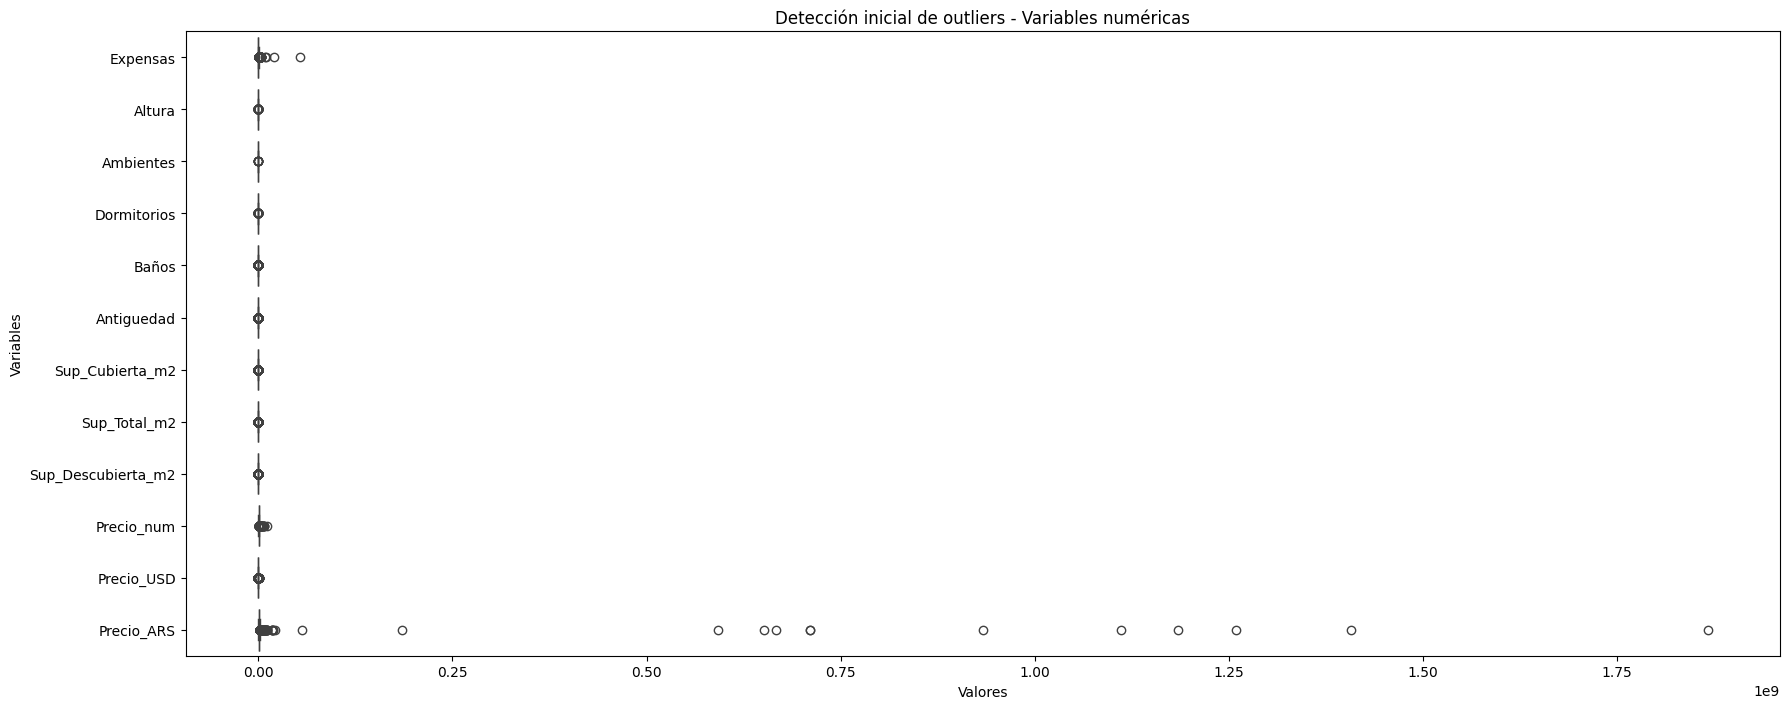

In [ ]:
# Seleccionar variables numéricas
variables_numericas = df_alquiler_completo.select_dtypes(
    include=['int64', 'float64']
).columns

variables_numericas = [
    col for col in variables_numericas
    if df_alquiler_completo[col].nunique() > 2
]

# Tamaño dinámico según cantidad de variables
plt.figure(figsize=(18, len(variables_numericas) * 0.6))

# Boxplot horizontal
sns.boxplot(
    data=df_alquiler_completo[variables_numericas],
    orient='h'
)

plt.title('Detección inicial de outliers - Variables numéricas')
plt.xlabel('Valores')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

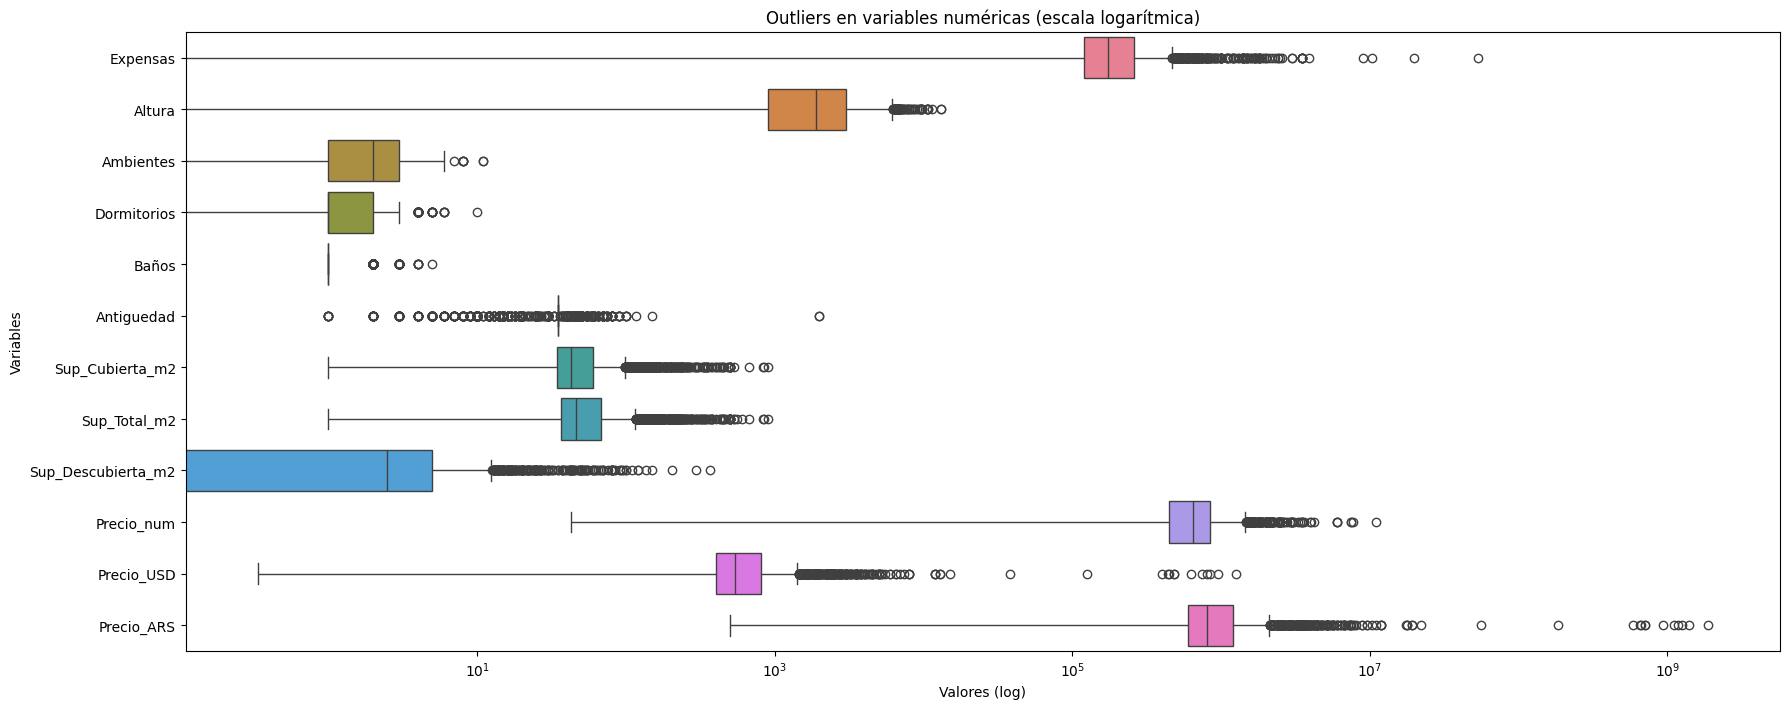

In [ ]:
plt.figure(figsize=(18, len(variables_numericas) * 0.6))

sns.boxplot(
    data=df_alquiler_completo[variables_numericas],
    orient='h'
)

plt.xscale('log')

plt.title('Outliers en variables numéricas (escala logarítmica)')
plt.xlabel('Valores (log)')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

###Expensas:

In [ ]:
df_alquiler_completo['Expensas'].describe(
    percentiles=[0.90,0.95,0.99]
)

,Expensas
count,3.662000e+03
mean,2.643814e+05
std,9.986201e+05
min,0.000000e+00
50%,1.745000e+05
90%,3.900000e+05
95%,5.699660e+05
99%,1.619500e+06
max,5.323500e+07


In [ ]:
df_alquiler_completo[
    df_alquiler_completo['Expensas'] >
    df_alquiler_completo['Expensas'].quantile(0.99)
][['Precio_USD','Precio_ARS', 'Expensas', 'Sup_Total_m2', 'Tipo_Unidad']]

,Precio_USD,Precio_ARS,Expensas,Sup_Total_m2,Tipo_Unidad
648,4500.000000,6665400.0,1900000.0,200.000,Departamento
734,5500.000000,8146600.0,1800000.0,200.000,Departamento
781,4500.000000,6665400.0,2000000.0,200.000,Departamento
879,2500.000000,3703000.0,1790000.0,211.000,Piso
891,2700.000000,3999240.0,1800000.0,211.000,Departamento
2137,8000.000000,11849600.0,2500000.0,676.480,Departamento
2139,3800.000000,5628560.0,1800000.0,270.130,Departamento
2145,38000.000000,56285600.0,20000000.0,2.256,Departamento
2360,7426.411018,11000000.0,1700000.0,1.439,Departamento
2365,1500.000000,2221800.0,2190000.0,229.050,Departamento


In [ ]:
#Detectar expensas absurdas respecto al precio
df_alquiler_completo['ratio_expensas_precio'] = (
    df_alquiler_completo['Expensas'] /
    df_alquiler_completo['Precio_ARS']
)

In [ ]:
df_alquiler_completo['ratio_expensas_precio'].describe(
    percentiles=[0.90,0.95,0.99]
)

,ratio_expensas_precio
count,3662.000000
mean,0.540017
std,8.686341
min,0.000000
50%,0.211765
90%,0.362022
95%,0.428571
99%,0.755319
max,310.000000


In [ ]:
outliers_expensas = df_alquiler_completo[
    df_alquiler_completo['ratio_expensas_precio'] > 0.05
]

In [ ]:
#Imputar esos outliers con NaN para luego imputar nuevamente
df_alquiler_completo.loc[
    df_alquiler_completo['ratio_expensas_precio'] > 0.05,
    'Expensas'
] = np.nan

In [ ]:
#Imputacion
df_alquiler_completo.groupby('Tipo_Unidad')['Expensas'].apply(
    lambda x: x.isnull().mean()*100
)

,Expensas
Tipo_Unidad,
Casa,0.000000
Departamento,98.147612
Duplex,100.000000
Loft,100.000000
Ph,38.461538
Piso,100.000000
Semipiso,100.000000


In [ ]:
df_alquiler_completo['Expensas'] = (
    df_alquiler_completo.groupby(
        ['Tipo_Unidad', 'rango_sup']
    )['Expensas']
    .transform(lambda x: x.fillna(x.median()))
)

/tmp/ipykernel_12042/2227923336.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_alquiler_completo.groupby(


In [ ]:
mediana_expensas = df_alquiler_completo['Expensas'].median()

df_alquiler_completo['Expensas'] = (
    df_alquiler_completo['Expensas']
    .fillna(mediana_expensas)
)

###Precio_USD:

In [ ]:
#revisar percentiles
df_alquiler_completo['Precio_USD'].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

,Precio_USD
count,3.663000e+03
mean,2.850559e+03
std,3.986895e+04
min,3.375641e-01
1%,2.350122e+02
5%,3.038077e+02
25%,4.050770e+02
50%,5.401026e+02
75%,8.101539e+02
95%,2.000000e+03


In [ ]:
#revisar los minimos
df_alquiler_completo.sort_values(
    'Precio_USD'
)[[
    'Precio_USD',
    'Sup_Total_m2',
    'Tipo_Unidad',
    'Precio'
]].head(20)

,Precio_USD,Sup_Total_m2,Tipo_Unidad,Precio
1014,0.337564,37.00,Departamento,ARS 500
234,0.371321,39.00,Departamento,ARS 550
748,0.668377,50.00,Departamento,ARS 990
1027,0.675128,130.00,Departamento,ARS 1.000
1068,43.000000,23.00,Departamento,USD 43
1038,54.010262,42.00,Departamento,ARS 80.000
3653,54.010262,2.10,Departamento,80.000 ARS
4026,60.761545,14.24,Departamento,90.000 ARS
3726,67.512827,7.00,Departamento,100.000 ARS
714,93.167702,50.00,Loft,ARS 138.000


### Corrección automática de precios mal etiquetados

Basándonos en la observación de que algunos precios muy bajos etiquetados como ARS (por ejemplo, 500 ARS) en realidad corresponden a valores en USD mal categorizados, crearemos una función para corregir automáticamente estos casos. La lógica será la siguiente:

1.  **Identificación:** Si la columna `Moneda` es 'ARS' y el `Precio_num` (el valor numérico extraído del precio) es menor a un umbral determinado (por ejemplo, 2000), se considera que este precio fue mal etiquetado.
    *   Un valor de 2000 ARS, convertido a USD, sería aproximadamente 1.35 USD (usando un tipo de cambio de 1481.2 ARS/USD). Un valor tan bajo es irreal para una propiedad, lo que sugiere que el `Precio_num` original (ej. 500) era el valor real en USD, no en ARS.
2.  **Corrección:** Para los registros identificados, la `Moneda` se cambiará a 'USD'.
3.  **Recalculación:** `Precio_USD` se establecerá directamente al `Precio_num` original (ya que este era el valor en USD deseado). `Precio_ARS` se recalculará multiplicando este nuevo `Precio_USD` por el tipo de cambio CCL.

In [ ]:
def corregir_precios_malo_etiquetados(df, tc_usd_value, threshold_precio_num_ars=2000):

    # Identificar filas donde Moneda es ARS y Precio_num es sospechosamente bajo
    mislabeled_mask = (
        (df['Moneda'] == 'ARS') &
        (df['Precio_num'] < threshold_precio_num_ars)
    )

    # Contar cuántas filas están siendo corregidas
    num_corrections = mislabeled_mask.sum()
    print(f"Número de precios mal etiquetados identificados y corregidos: {num_corrections}")

    if num_corrections > 0:
        # Para estas filas mal etiquetadas, actualizar la 'Moneda' a 'USD'
        df.loc[mislabeled_mask, 'Moneda'] = 'USD'

        # El 'Precio_num' en estos casos era el valor USD intended, así que establecemos Precio_USD directamente
        df.loc[mislabeled_mask, 'Precio_USD'] = df.loc[mislabeled_mask, 'Precio_num']

        # Recalcular 'Precio_ARS' usando el nuevo 'Precio_USD' y el tipo de cambio
        df.loc[mislabeled_mask, 'Precio_ARS'] = df.loc[mislabeled_mask, 'Precio_num'] * tc_usd_value

        # Redondear para mayor legibilidad
        df.loc[mislabeled_mask, 'Precio_USD'] = df.loc[mislabeled_mask, 'Precio_USD'].round(2)
        df.loc[mislabeled_mask, 'Precio_ARS'] = df.loc[mislabeled_mask, 'Precio_ARS'].round(0)

    return df

# Aplicar la función al DataFrame
df_alquiler_completo = corregir_precios_malo_etiquetados(
    df_alquiler_completo,
    TC_USD
)


Número de precios mal etiquetados identificados y corregidos: 4


In [ ]:
# Verificar los precios mínimos después de la corrección
df_alquiler_completo.sort_values(
    'Precio_USD'
)[[
    'Precio_USD',
    'Sup_Total_m2',
    'Tipo_Unidad',
    'Precio',
    'Moneda',
    'Precio_num'
]].head(20)

,Precio_USD,Sup_Total_m2,Tipo_Unidad,Precio,Moneda,Precio_num
1068,43.000000,23.00,Departamento,USD 43,USD,43.0
1038,54.010262,42.00,Departamento,ARS 80.000,ARS,80000.0
3653,54.010262,2.10,Departamento,80.000 ARS,ARS,80000.0
4026,60.761545,14.24,Departamento,90.000 ARS,ARS,90000.0
3726,67.512827,7.00,Departamento,100.000 ARS,ARS,100000.0
714,93.167702,50.00,Loft,ARS 138.000,ARS,138000.0
2162,121.523089,52.60,Departamento,180.000 ARS,ARS,180000.0
4032,121.523089,35.00,Departamento,180.000 ARS,ARS,180000.0
2610,128.274372,12.00,Departamento,190.000 ARS,ARS,190000.0
3300,162.030786,40.00,Departamento,240.000 ARS,ARS,240000.0


In [ ]:
df_alquiler_completo.nlargest(15, 'Precio_USD')[
    [
    'Precio_USD',
    'Sup_Total_m2',
    'Tipo_Unidad',
    'Precio',
    'Moneda',
    'Precio_num'
]
]
# debo crear una nueva funcion que corrija los precios mal etiquetados de forma opuesta. si observa valores en Precio_USD mayores a 15000 entonces debería asumir que en realidad ese valor deberia ser pesos

,Precio_USD,Sup_Total_m2,Tipo_Unidad,Precio,Moneda,Precio_num
2089,1260000.0,66.000,Departamento,1.260.000 USD,USD,1260000.0
966,950000.0,40.000,Departamento,USD 950.000,USD,950000.0
1525,850000.0,80.000,Departamento,USD 850.000,USD,850000.0
1789,800000.0,64.000,Departamento,USD 800.000,USD,800000.0
2112,750000.0,42.400,Departamento,750.000 USD,USD,750000.0
1461,630000.0,40.000,Departamento,USD 630.000,USD,630000.0
1608,480000.0,45.000,Departamento,USD 480.000,USD,480000.0
1644,480000.0,45.000,Departamento,USD 480.000,USD,480000.0
958,450000.0,30.000,Departamento,USD 450.000,USD,450000.0
1148,440000.0,30.000,Departamento,USD 440.000,USD,440000.0


### Corrección de precios altos en USD que probablemente son ARS

Continuando con la limpieza de datos monetarios, hemos identificado una nueva categoría de errores: propiedades con valores de `Precio_USD` anormalmente altos (por ejemplo, superiores a 15,000 USD) que, tras una inspección, se determinó que eran valores en ARS incorrectamente etiquetados como USD.

Para abordar esto, se implementará una nueva función `corregir_precios_altos_usd_malo_etiquetados`. La lógica es la siguiente:

1.  **Identificación:** Se buscarán registros donde la `Moneda` sea 'USD' y el `Precio_num` (el valor numérico original extraído) sea mayor a un umbral definido (por ejemplo, 15,000).
2.  **Corrección:** Para estos registros, la `Moneda` se cambiará a 'ARS'.
3.  **Recalculación:**
    *   `Precio_ARS` se establecerá directamente al `Precio_num` original (ya que este era el valor en ARS deseado).
    *   `Precio_USD` se recalculará dividiendo este nuevo `Precio_ARS` por el tipo de cambio CCL (`TC_USD`).

In [ ]:
def corregir_precios_altos_usd_malo_etiquetados(df, tc_usd_value, threshold_precio_usd_high=15000):
    # Identificar filas donde Moneda es USD y Precio_num es sospechosamente alto
    mislabeled_mask = (
        (df['Moneda'] == 'USD') &
        (df['Precio_num'] > threshold_precio_usd_high)
    )

    num_corrections = mislabeled_mask.sum()
    print(f"Número de precios USD altos mal etiquetados identificados y corregidos: {num_corrections}")

    if num_corrections > 0:
        # Para estas filas mal etiquetadas, actualizar la 'Moneda' a 'ARS'
        df.loc[mislabeled_mask, 'Moneda'] = 'ARS'

        # El 'Precio_num' original en estos casos era el valor ARS intended
        df.loc[mislabeled_mask, 'Precio_ARS'] = df.loc[mislabeled_mask, 'Precio_num']

        # Recalcular 'Precio_USD' usando el nuevo 'Precio_ARS' y el tipo de cambio
        df.loc[mislabeled_mask, 'Precio_USD'] = df.loc[mislabeled_mask, 'Precio_num'] / tc_usd_value

        # Redondear para mayor legibilidad
        df.loc[mislabeled_mask, 'Precio_USD'] = df.loc[mislabeled_mask, 'Precio_USD'].round(2)
        df.loc[mislabeled_mask, 'Precio_ARS'] = df.loc[mislabeled_mask, 'Precio_ARS'].round(0)

    return df

# Aplicar la nueva función al DataFrame
df_alquiler_completo = corregir_precios_altos_usd_malo_etiquetados(
    df_alquiler_completo,
    TC_USD
)

# Verificar los precios más altos después de la corrección
df_alquiler_completo.nlargest(15, 'Precio_USD')[
    [
    'Precio_USD',
    'Sup_Total_m2',
    'Tipo_Unidad',
    'Precio',
    'Moneda',
    'Precio_num'
]
]

Número de precios USD altos mal etiquetados identificados y corregidos: 13


,Precio_USD,Sup_Total_m2,Tipo_Unidad,Precio,Moneda,Precio_num
3459,15000.000000,1.000,Departamento,15.000 USD,USD,15000.0
3807,13000.000000,500.000,Departamento,13.000 USD,USD,13000.0
3808,13000.000000,500.000,Departamento,13.000 USD,USD,13000.0
3822,12000.000000,500.000,Departamento,12.000 USD,USD,12000.0
3823,12000.000000,500.000,Departamento,12.000 USD,USD,12000.0
3804,11900.000000,500.000,Departamento,11.900 USD,USD,11900.0
2137,8000.000000,676.480,Departamento,8.000 USD,USD,8000.0
2826,8000.000000,360.000,Departamento,8.000 USD,USD,8000.0
4018,8000.000000,340.950,Departamento,8.000 USD,USD,8000.0
2360,7426.411018,1.439,Departamento,11.000.000 ARS,ARS,11000000.0


###Sup_Total_m2:

In [ ]:
df_alquiler_completo['Sup_Total_m2'].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

,Sup_Total_m2
count,3663.000000
mean,63.413439
std,59.515663
min,1.000000
1%,20.000000
5%,26.238000
25%,36.395000
50%,46.000000
75%,68.000000
95%,152.333000


In [ ]:
df_alquiler_completo.sort_values(
    'Sup_Total_m2'
)[[
    'Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Precio_USD',
    'Tipo_Unidad',
    'Ambientes'
]].head(20)

,Sup_Total_m2,Sup_Cubierta_m2,Precio_USD,Tipo_Unidad,Ambientes
3459,1.000,1.000,15000.000000,Departamento,1.0
2360,1.439,1.439,7426.411018,Departamento,1.0
3481,1.863,1.863,5198.487713,Departamento,1.0
3653,2.100,2.100,54.010262,Departamento,1.0
2145,2.256,2.256,25.650000,Departamento,1.0
1844,3.000,3.000,337.564137,Departamento,1.0
544,3.724,3.357,371.320551,Departamento,1.0
2198,4.100,4.100,405.076965,Departamento,2.0
292,5.000,50.000,600.000000,Departamento,2.0
3726,7.000,7.000,67.512827,Departamento,1.0


In [ ]:
#eliminacion de valores menores a 9 ya que es muy dificil que eso representa a una propiedad real.
df_alquiler_completo = df_alquiler_completo[
    df_alquiler_completo['Sup_Total_m2'] >= 9
]

###Sup_Cubierta_m2:

In [ ]:
#validacion de coherencia logica
df_alquiler_completo = df_alquiler_completo[
    df_alquiler_completo['Sup_Cubierta_m2']
    <=
    df_alquiler_completo['Sup_Total_m2']
]

In [ ]:
df_alquiler_completo.nlargest(20, 'Sup_Cubierta_m2')[
    [
        'Tipo_Unidad',
        'Sup_Cubierta_m2',
        'Sup_Total_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Sup_Cubierta_m2,Sup_Total_m2,Precio_USD
3477,Departamento,900.00,900.00,3800.000000
3973,Departamento,850.00,850.00,6500.000000
3396,Departamento,839.00,839.00,4050.769646
2137,Departamento,676.48,676.48,8000.000000
3010,Departamento,530.00,530.00,1500.000000
3603,Departamento,500.00,500.00,6500.000000
3804,Departamento,500.00,500.00,11900.000000
3807,Departamento,500.00,500.00,13000.000000
3808,Departamento,500.00,500.00,13000.000000
3822,Departamento,500.00,500.00,12000.000000


Se analizaron los valores extremos de la variable Sup_Cubierta_m2 mediante percentiles y revisión manual de los registros máximos. Si bien existen superficies considerablemente altas, estas resultaron plausibles dentro del mercado inmobiliario y coherentes con la superficie total y el precio de las propiedades. Por lo tanto, no se eliminaron registros únicamente por presentar valores elevados.

###Sup_Descubierta_m2:

In [ ]:
df_alquiler_completo = df_alquiler_completo[
    df_alquiler_completo['Sup_Descubierta_m2']
    <=
    df_alquiler_completo['Sup_Total_m2']
]

In [ ]:
df_alquiler_completo.nlargest(20, 'Sup_Descubierta_m2')[
    [
        'Tipo_Unidad',
        'Sup_Descubierta_m2',
        'Sup_Total_m2',
        'Sup_Cubierta_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Sup_Descubierta_m2,Sup_Total_m2,Sup_Cubierta_m2,Precio_USD
2551,Departamento,295.00,321.86,26.86,398.325682
2569,Departamento,205.00,600.00,395.00,2362.948960
1665,Departamento,150.00,500.00,350.00,2300.000000
725,Departamento,137.00,252.00,115.00,6990.000000
1572,Departamento,120.00,450.00,330.00,1957.871996
3612,Departamento,120.00,459.00,339.00,3600.000000
1374,Departamento,110.00,461.00,351.00,1235.484742
1316,Piso,100.00,200.00,100.00,1147.718066
2035,Departamento,100.00,200.00,100.00,1600.000000
2032,Departamento,95.00,181.00,86.00,1700.000000


In [ ]:
propiedades_descubierta_mayor_cubierta = df_alquiler_completo[
    df_alquiler_completo['Sup_Descubierta_m2'] > df_alquiler_completo['Sup_Cubierta_m2']
].copy()

print(f"Número de propiedades donde Sup_Descubierta_m2 > Sup_Cubierta_m2: {len(propiedades_descubierta_mayor_cubierta)}")

Número de propiedades donde Sup_Descubierta_m2 > Sup_Cubierta_m2: 20


Se considera que los valores de la entrada 2551 son extremadamente irrisorios como para ser realistas. Por lo que se supone un error de scrapeo o, de imputación por parte del corredor, ingresando al link se confirma lo último al observar un balcón que es más pequeño que la superficie cubierta. Es decir que esa superficie total imputada es errónea, por lo que Sup_descubierta_m2 es reemplazada por la media. Mientras que Sup_total_m2 será reemplazada por la suma de la anterior con Sup_Cubierta_m2

In [ ]:
propiedades_descubierta_mucho_mayor_cubierta = df_alquiler_completo[
    df_alquiler_completo['Sup_Descubierta_m2'] > (1.75 * df_alquiler_completo['Sup_Cubierta_m2'])
].copy()

print(f"Número de propiedades donde Sup_Descubierta_m2 es más de un 75% mayor que Sup_Cubierta_m2: {len(propiedades_descubierta_mucho_mayor_cubierta)}")

display(propiedades_descubierta_mucho_mayor_cubierta.sort_values('Sup_Descubierta_m2',ascending=False)[
    [
        'Sup_Descubierta_m2',
        'Sup_Cubierta_m2',
        'Sup_Total_m2',
        'Precio_ARS',
        'Ambientes',
        'Dormitorios'
    ]
])

Número de propiedades donde Sup_Descubierta_m2 es más de un 75% mayor que Sup_Cubierta_m2: 4


,Sup_Descubierta_m2,Sup_Cubierta_m2,Sup_Total_m2,Precio_ARS,Ambientes,Dormitorios
2551,295.0,26.86,321.86,590000.0,1.0,0.0
1779,80.0,40.00,120.00,650000.0,2.0,1.0
1942,60.0,5.00,65.00,800000.0,3.0,2.0
1317,30.0,3.00,33.00,500000.0,1.0,0.0


In [ ]:
pd.set_option('display.max_colwidth', None)

df_alquiler_completo.loc[[2551], 'Link']

,Link
2551,https://www.remax.com.ar/listings/alquiler-monoambiente-al-fte-parque-chas


In [ ]:
median_sup_descubierta = df_alquiler_completo['Sup_Descubierta_m2'].mean()

# Reemplazar Sup_Descubierta_m2 en el índice 2551 con la mediana
df_alquiler_completo.loc[2551, 'Sup_Descubierta_m2'] = median_sup_descubierta

# Recalcular Sup_Total_m2 en el índice 2551
df_alquiler_completo.loc[2551, 'Sup_Total_m2'] = (
    df_alquiler_completo.loc[2551, 'Sup_Cubierta_m2'] +
    df_alquiler_completo.loc[2551, 'Sup_Descubierta_m2']
)

# Verificar los cambios en la fila 2551
display(df_alquiler_completo.loc[[2551], ['Sup_Cubierta_m2', 'Sup_Descubierta_m2', 'Sup_Total_m2']])

,Sup_Cubierta_m2,Sup_Descubierta_m2,Sup_Total_m2
2551,26.86,4.663807,31.523807


El análisis permitió observar que muchos de estos registros resultan plausibles dentro del contexto inmobiliario, especialmente en propiedades con:

* terrazas amplias,
* patios,
* balcones grandes,
* o espacios semicubiertos.

###Ambientes:

In [ ]:
df_alquiler_completo.nlargest(20, 'Ambientes')[
    [
        'Tipo_Unidad',
        'Ambientes',
        'Dormitorios',
        'Baños',
        'Sup_Total_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Ambientes,Dormitorios,Baños,Sup_Total_m2,Precio_USD
1971,Departamento,11.0,10.0,2,350.00,1012.692412
2569,Departamento,11.0,6.0,1,600.00,2362.948960
67,Piso,8.0,4.0,4,250.00,1687.820686
1386,Piso,8.0,6.0,1,322.00,1350.256549
3477,Departamento,8.0,6.0,1,900.00,3800.000000
3785,Departamento,8.0,4.0,1,199.00,2000.000000
1374,Departamento,7.0,6.0,4,461.00,1235.484742
48,Departamento,6.0,4.0,1,275.00,2400.000000
281,Duplex,6.0,4.0,3,215.00,2450.000000
772,Piso,6.0,5.0,1,290.00,3900.000000


En estos registros, la relación entre cantidad de ambientes, dormitorios y superficie total resulta poco habitual, lo que podría indicar:

- errores de carga,
- criterios distintos de contabilización de ambientes,
- o propiedades no residenciales mal clasificadas.

No obstante, debido a la falta de información adicional que permita confirmar inconsistencias, se decidió no eliminar automáticamente estos registros en esta etapa del análisis.

Por lo tanto, la variable Ambientes fue conservada sin recortes automáticos, priorizando mantener propiedades extremas pero plausibles dentro del mercado inmobiliario.

###Dormitorios:

In [ ]:
df_alquiler_completo.nlargest(20, 'Dormitorios')[
    [
        'Tipo_Unidad',
        'Dormitorios',
        'Ambientes',
        'Baños',
        'Sup_Total_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Dormitorios,Ambientes,Baños,Sup_Total_m2,Precio_USD
1971,Departamento,10.0,11.0,2,350.00,1012.692412
1374,Departamento,6.0,7.0,4,461.00,1235.484742
1386,Piso,6.0,8.0,1,322.00,1350.256549
2569,Departamento,6.0,11.0,1,600.00,2362.948960
3477,Departamento,6.0,8.0,1,900.00,3800.000000
772,Piso,5.0,6.0,1,290.00,3900.000000
951,Departamento,5.0,6.0,3,230.00,1800.000000
1572,Departamento,5.0,6.0,1,450.00,1957.871996
1665,Departamento,5.0,6.0,5,500.00,2300.000000
2139,Departamento,5.0,6.0,1,270.13,3800.000000


In [ ]:
#Eliminacion con filtro para no eliminar propiedades de lujo
df_alquiler_completo = df_alquiler_completo[
    ~(
        (df_alquiler_completo['Dormitorios'] >= 6) &
        (df_alquiler_completo['Sup_Total_m2'] < 150)
    )
]

#Exportar csv


In [ ]:
df_alquiler_completo.to_csv('dataset_alquiler_limpio.csv', index=False)